<a href="https://colab.research.google.com/github/krishnacharyaprabhakar-lgtm/AI-Ophthalmology-Dashboard/blob/main/pva_study_Egypt_30_8_26.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np


In [ ]:
import pandas as pd
df = pd.read_excel('/content/drive/MyDrive/AK and AR 1wk, 6wk and 3 months 011225.xlsx')

In [ ]:
sheets = pd.ExcelFile('/content/drive/MyDrive/AK and AR 1wk, 6wk and 3 months 011225.xlsx')

In [ ]:
sheets.sheet_names

['raw data', 'data 1wk, 6wk and 3 months', 'sorted data']

In [ ]:
raw_data = sheets.parse('raw data')
raw_data.shape

(174, 18)

In [ ]:
raw_data.head()

,Age,Gender,PreopR1,PreopR2,PreopA1,PreopVA,POD 1wkVA,Sph1wk,Cyl1wk,Axis1wk,POD 6wkVA,Sph6wk,Cyl6wk,Axis6wk,POD 3mthVA,Sph3mth,Cyl3mth,Axis3mth
0,54,F,46.50,47.25,155,6\24,6\12,0.25,-1.50,115.0,6\12,0.25,-1.25,100.0,6\9,0.5,-1.0,65.0
1,63,F,46.75,48.00,80,HM,6\18,0.75,-2.25,80.0,6\18,0.75,-2.00,90.0,6\12,0.5,-2.0,80.0
2,78,F,44.00,44.25,20,6\60,6\24,NO CENTER,NaN,NaN,6\24,-1.5,-1.00,140.0,NaN,NaN,NaN,NaN
3,71,F,45.25,45.75,120,CF@1M,6\18,-0.75,-1.00,160.0,6\18,-0.5,-0.75,140.0,6\9,-0.5,-0.5,150.0
4,89,M,45.50,47.00,80,6\36,6\12,0.25,2.00,75.0,6\12,0.25,2.25,85.0,NaN,NaN,NaN,NaN


In [ ]:
raw_data.isnull().sum()

,0
Age,0
Gender,0
PreopR1,0
PreopR2,0
PreopA1,0
PreopVA,0
POD 1wkVA,0
Sph1wk,2
Cyl1wk,43
Axis1wk,43


In [ ]:
raw_data.columns

Index(['Age', 'Gender ', 'PreopR1', 'PreopR2', 'PreopA1', 'PreopVA',
       'POD 1wkVA', 'Sph1wk', 'Cyl1wk', 'Axis1wk', 'POD 6wkVA', 'Sph6wk ',
       'Cyl6wk', 'Axis6wk', 'POD 3mthVA', 'Sph3mth', 'Cyl3mth', 'Axis3mth'],
      dtype='object')

In [ ]:
raw_data.isnull().sum()

,0
Age,0
Gender,0
PreopR1,0
PreopR2,0
PreopA1,0
PreopVA,0
POD 1wkVA,0
Sph1wk,2
Cyl1wk,43
Axis1wk,43


In [ ]:
sorted_data = sheets.parse('sorted data')
sorted_data.isnull().sum()

,0
Age,0
Gender,0
PreopR1,0
PreopR2,0
PreopA1,0
Sph1wk,2
Cyl1wk,41
Axis1wk,41
Sph6wk,1
Cyl6wk,3


In [ ]:
sorted_data.shape

(172, 14)

In [ ]:
sorted_data.columns

Index(['Age', 'Gender ', 'PreopR1', 'PreopR2', 'PreopA1', 'Sph1wk', 'Cyl1wk',
       'Axis1wk', 'Sph6wk ', 'Cyl6wk', 'Axis6wk', 'Sph3mth', 'Cyl3mth',
       'Axis3mth'],
      dtype='object')

In [ ]:
sorted_data.columns = sorted_data.columns.str.strip()


In [ ]:
sorted_data.dropna(subset=['Sph3mth', 'Cyl3mth','Axis3mth'],inplace=True)
sorted_data.isnull().sum()

,0
Age,0
Gender,0
PreopR1,0
PreopR2,0
PreopA1,0
Sph1wk,2
Cyl1wk,23
Axis1wk,23
Sph6wk,0
Cyl6wk,0


In [ ]:
sorted_data.dropna(subset=['Sph1wk', 'Cyl1wk','Axis1wk'],inplace=True)
sorted_data.isnull().sum()

,0
Age,0
Gender,0
PreopR1,0
PreopR2,0
PreopA1,0
Sph1wk,0
Cyl1wk,0
Axis1wk,0
Sph6wk,0
Cyl6wk,0


In [ ]:
sorted_data.columns

Index(['Age', 'Gender', 'PreopR1', 'PreopR2', 'PreopA1', 'Sph1wk', 'Cyl1wk',
       'Axis1wk', 'Sph6wk', 'Cyl6wk', 'Axis6wk', 'Sph3mth', 'Cyl3mth',
       'Axis3mth'],
      dtype='object')

In [ ]:
sorted_data.shape

(87, 14)

In [ ]:
from scipy import stats
age = sorted_data['Age'].dropna()

n = age.count()
mean = age.mean()
sd = age.std()
sem = sd / np.sqrt(n)
median = age.median()
min_val = age.min()
max_val = age.max()
skew = age.skew()
kurtosis = age.kurt()
ci_low, ci_high = stats.t.interval(0.95, n-1, loc=mean, scale=sem)

age_table_single = pd.DataFrame({
    'Age': [
        n,
        round(mean, 2),
        round(sd, 2),
        round(sem, 2),
        round(median, 2),
        min_val,
        max_val,
        round(skew, 2),
        round(kurtosis, 2),
        f"{round(ci_low,2)} – {round(ci_high,2)}"
    ]
}, index=[
    'Count',
    'Mean',
    'SD',
    'SEM',
    'Median',
    'Min',
    'Max',
    'Skew',
    'Kurtosis',
    '95% CI'
])

age_table_single


,Age
Count,87
Mean,63.51
SD,9.48
SEM,1.02
Median,65.0
Min,38
Max,84
Skew,-0.16
Kurtosis,-0.31
95% CI,61.48 – 65.53


Age, stratified by Gender.

In [ ]:
def age_summary(series):
    series = series.dropna()
    n = series.count()
    mean = series.mean()
    sd = series.std()
    sem = sd / np.sqrt(n)
    median = series.median()
    min_val = series.min()
    max_val = series.max()
    skew = series.skew()
    kurtosis = series.kurt()
    ci_low, ci_high = stats.t.interval(0.95, n-1, loc=mean, scale=sem)

    return pd.Series([
        n,
        round(mean, 2),
        round(sd, 2),
        round(sem, 2),
        round(median, 2),
        min_val,
        max_val,
        round(skew, 2),
        round(kurtosis, 2),
        f"{round(ci_low,2)} – {round(ci_high,2)}"
    ], index=[
        'Count',
        'Mean',
        'SD',
        'SEM',
        'Median',
        'Min',
        'Max',
        'Skew',
        'Kurtosis',
        '95% CI'
    ])

age_by_gender = sorted_data.groupby('Gender')['Age'].apply(age_summary)

age_by_gender


Gender          
F       Count                  53
        Mean                63.11
        SD                   8.94
        SEM                  1.23
        Median               63.0
        Min                    46
        Max                    83
        Skew                 0.01
        Kurtosis            -0.58
        95% CI      60.65 – 65.58
M       Count                  34
        Mean                64.12
        SD                  10.38
        SEM                  1.78
        Median               66.5
        Min                    38
        Max                    84
        Skew                -0.39
        Kurtosis             0.06
        95% CI       60.5 – 67.74
Name: Age, dtype: object

In [ ]:
sorted_data['Preop_cyl'] = sorted_data['PreopR2'] - sorted_data['PreopR1']
sorted_data['Preop_meanK'] = (sorted_data['PreopR1'] + sorted_data['PreopR2']) / 2
sorted_data['Preop_SE'] = sorted_data['Preop_cyl'] / 2
sorted_data['steep_axis'] = (sorted_data['PreopA1'] + 90) % 180


In [ ]:
sorted_data.head()

,Age,Gender,PreopR1,PreopR2,PreopA1,Sph1wk,Cyl1wk,Axis1wk,Sph6wk,Cyl6wk,Axis6wk,Sph3mth,Cyl3mth,Axis3mth,Preop_cyl,Preop_meanK,Preop_SE,steep_axis
0,54,F,46.50,47.25,155,0.25,-1.50,115.0,0.25,-1.25,100.0,0.50,-1.00,65.0,0.75,46.875,0.375,65
1,63,F,46.75,48.00,80,0.75,-2.25,80.0,0.75,-2.00,90.0,0.50,-2.00,80.0,1.25,47.375,0.625,170
3,71,F,45.25,45.75,120,-0.75,-1.00,160.0,-0.5,-0.75,140.0,-0.50,-0.50,150.0,0.50,45.500,0.250,30
5,59,F,42.50,43.50,75,2,-2.00,90.0,1.75,-2.00,80.0,1.75,-2.25,80.0,1.00,43.000,0.500,165
7,63,F,43.00,44.50,90,-1,-0.50,100.0,-0.5,-2.25,80.0,-0.50,-1.50,70.0,1.50,43.750,0.750,0


In [ ]:
def classify_astigmatism(axis):
    if 60 <= axis <= 120:
        return 'WTR'
    elif axis <= 30 or axis >= 150:
        return 'ATR'
    else:
        return 'Oblique'

sorted_data['astigmatism_steeptype'] = sorted_data['steep_axis'].apply(classify_astigmatism)


In [ ]:
count = sorted_data['astigmatism_steeptype'].value_counts()

percentage = sorted_data['astigmatism_steeptype'].value_counts(normalize=True) * 100

result = pd.DataFrame({
    'Count': count,
    'Percentage': percentage.round(2)
})

print(result)


                       Count  Percentage
astigmatism_steeptype                   
ATR                       40       45.98
WTR                       32       36.78
Oblique                   15       17.24


In [ ]:
sorted_data.head()

,Age,Gender,PreopR1,PreopR2,PreopA1,Sph1wk,Cyl1wk,Axis1wk,Sph6wk,Cyl6wk,Axis6wk,Sph3mth,Cyl3mth,Axis3mth,Preop_cyl,Preop_meanK,Preop_SE,steep_axis,astigmatism_steeptype
0,54,F,46.50,47.25,155,0.25,-1.50,115.0,0.25,-1.25,100.0,0.50,-1.00,65.0,0.75,46.875,0.375,65,WTR
1,63,F,46.75,48.00,80,0.75,-2.25,80.0,0.75,-2.00,90.0,0.50,-2.00,80.0,1.25,47.375,0.625,170,ATR
3,71,F,45.25,45.75,120,-0.75,-1.00,160.0,-0.5,-0.75,140.0,-0.50,-0.50,150.0,0.50,45.500,0.250,30,ATR
5,59,F,42.50,43.50,75,2,-2.00,90.0,1.75,-2.00,80.0,1.75,-2.25,80.0,1.00,43.000,0.500,165,ATR
7,63,F,43.00,44.50,90,-1,-0.50,100.0,-0.5,-2.25,80.0,-0.50,-1.50,70.0,1.50,43.750,0.750,0,ATR


In [ ]:
preopcyl = sorted_data['Preop_cyl'].dropna()

n = preopcyl.count()
mean = preopcyl.mean()
sd = preopcyl.std()
sem = sd / np.sqrt(n)
median = preopcyl.median()
min_val = preopcyl.min()
max_val = preopcyl.max()
skew = preopcyl.skew()
kurtosis = preopcyl.kurt()

ci_low, ci_high = stats.t.interval(
    0.95,
    df=n-1,
    loc=mean,
    scale=sem
)

preopcyl_table_single = pd.DataFrame({
    'Preop_cyl': [
        n,
        round(mean, 2),
        round(sd, 2),
        round(sem, 2),
        round(median, 2),
        min_val,
        max_val,
        round(skew, 2),
        round(kurtosis, 2),
        f"{round(ci_low, 2)} – {round(ci_high, 2)}"
    ]
}, index=[
    'Count',
    'Mean',
    'SD',
    'SEM',
    'Median',
    'Min',
    'Max',
    'Skew',
    'Kurtosis',
    '95% CI'
])

preopcyl_table_single


,Preop_cyl
Count,87
Mean,0.86
SD,0.6
SEM,0.06
Median,0.75
Min,0.0
Max,3.0
Skew,1.25
Kurtosis,1.54
95% CI,0.74 – 0.99


In [ ]:
preop_meanK = sorted_data['Preop_meanK'].dropna()

n = preop_meanK.count()
mean = preop_meanK.mean()
sd = preop_meanK.std()
sem = sd / np.sqrt(n)
median = preop_meanK.median()
min_val = preop_meanK.min()
max_val = preop_meanK.max()
skew = preop_meanK.skew()
kurtosis = preop_meanK.kurt()

ci_low, ci_high = stats.t.interval(
    0.95,
    n - 1,
    loc=mean,
    scale=sem
)

preop_meanK_table_single = pd.DataFrame({
    'Preop_meanK': [
        n,
        round(mean, 2),
        round(sd, 2),
        round(sem, 2),
        round(median, 2),
        min_val,
        max_val,
        round(skew, 2),
        round(kurtosis, 2),
        f"{round(ci_low, 2)} – {round(ci_high, 2)}"
    ]
}, index=[
    'Count',
    'Mean',
    'SD',
    'SEM',
    'Median',
    'Min',
    'Max',
    'Skew',
    'Kurtosis',
    '95% CI'
])

preop_meanK_table_single


,Preop_meanK
Count,87
Mean,44.89
SD,1.57
SEM,0.17
Median,44.88
Min,40.75
Max,49.0
Skew,0.05
Kurtosis,-0.04
95% CI,44.55 – 45.22


In [ ]:
preop_SE = sorted_data['Preop_SE'].dropna()

n = preop_SE.count()
mean = preop_SE.mean()
sd = preop_SE.std()
sem = sd / np.sqrt(n)
median = preop_SE.median()
min_val = preop_SE.min()
max_val = preop_SE.max()
skew = preop_SE.skew()
kurtosis = preop_SE.kurt()

ci_low, ci_high = stats.t.interval(
    0.95,
    n - 1,
    loc=mean,
    scale=sem
)

preop_SE_table_single = pd.DataFrame({
    'Preop_SE': [
        n,
        round(mean, 2),
        round(sd, 2),
        round(sem, 2),
        round(median, 2),
        round(min_val, 2),
        round(max_val, 2),
        round(skew, 2),
        round(kurtosis, 2),
        f"{round(ci_low, 2)} – {round(ci_high, 2)}"
    ]
}, index=[
    'Count',
    'Mean',
    'SD',
    'SEM',
    'Median',
    'Min',
    'Max',
    'Skew',
    'Kurtosis',
    '95% CI'
])

preop_SE_table_single


,Preop_SE
Count,87
Mean,0.43
SD,0.3
SEM,0.03
Median,0.38
Min,0.0
Max,1.5
Skew,1.25
Kurtosis,1.54
95% CI,0.37 – 0.5


## Revision
preopA1 is minus cylinder axis flat
so j0 and j45 are calculated,  minus minus cancels, the steep axis is the positive cylinder axis, but thibos minus cylindr advised,
so naturaly flat axis is the minus cylinder axis,so in the formula thibos minus cancels with the minus cylinder, then j9 j45 calculated




In [ ]:
theta_flat = np.deg2rad(sorted_data['PreopA1'])

sorted_data['Preop_J0'] = (
    sorted_data['Preop_cyl'] / 2
) * np.cos(2 * theta_flat)

sorted_data['Preop_J45'] = (
    sorted_data['Preop_cyl'] / 2
) * np.sin(2 * theta_flat)

sorted_data['Preop_J'] = np.sqrt(
    sorted_data['Preop_J0']**2 +
    sorted_data['Preop_J45']**2
)


minus cylinder code

In [ ]:
sorted_data['Preop_minuscyl'] = sorted_data['PreopR1'] - sorted_data['PreopR2']


In [ ]:
sorted_data['Preop_minuscyl']

,Preop_minuscyl
0,-0.75
1,-1.25
3,-0.50
5,-1.00
7,-1.50
...,...
159,-0.75
162,-2.00
163,-0.75
166,-0.50


In [ ]:
sorted_data['Preop_cyl']

,Preop_cyl
0,0.75
1,1.25
3,0.50
5,1.00
7,1.50
...,...
159,0.75
162,2.00
163,0.75
166,0.50


In [ ]:
def classify_astigmatism(axis):
    if 60 <= axis <= 120:
        return 'WTR'
    elif axis <= 30 or axis >= 150:
        return 'ATR'
    else:
        return 'Oblique'

sorted_data['Preop_astigmatism_type'] = (
    sorted_data['PreopA1'] % 180
).apply(classify_astigmatism)


In [ ]:
count_percent = (
    sorted_data['astigmatism_steeptype']
    .value_counts(dropna=False)
    .to_frame('Count')
)

count_percent['Percentage'] = (
    count_percent['Count'] / len(sorted_data) * 100
).round(2)

count_percent



,Count,Percentage
astigmatism_steeptype,,
ATR,40,45.98
WTR,32,36.78
Oblique,15,17.24


In [ ]:
theta_flat = np.deg2rad(sorted_data['PreopA1'])

# Convert negative-cylinder refraction to double-angle vectors
sorted_data['Preop_J0'] = (
    -sorted_data['Preop_minuscyl'] / 2
) * np.cos(2 * theta_flat)

sorted_data['Preop_J45'] = (
    -sorted_data['Preop_minuscyl'] / 2
) * np.sin(2 * theta_flat)

# Vector magnitude
sorted_data['Preop_J'] = np.sqrt(
    sorted_data['Preop_J0']**2 +
    sorted_data['Preop_J45']**2
)


def classify_astigmatism(axis):
    if pd.isna(axis):
        return np.nan
    if 60 <= axis <= 120:
        return 'WTR'
    elif axis <= 30 or axis >= 150:
        return 'ATR'
    else:
        return 'Oblique'


# Clinical astigmatism type from original cylinder axis
sorted_data['Preop_astigmatism_type'] = (
    sorted_data['PreopA1'] % 180
).apply(classify_astigmatism)


# Recover cylinder axis from J vectors
sorted_data['Preop_vector_axis'] = (
    0.5 * np.degrees(
        np.arctan2(
            -sorted_data['Preop_J45'],
            -sorted_data['Preop_J0']
        )
    )
) % 180


# Classify vector-derived axis
sorted_data['Preop_vectorastigmatism'] = (
    sorted_data['Preop_vector_axis']
    .apply(classify_astigmatism)
)


# Count and percentage
count_percent = (
    sorted_data['Preop_vectorastigmatism']
    .value_counts(dropna=False)
    .to_frame('Count')
)

valid_n = sorted_data['Preop_vectorastigmatism'].notna().sum()

count_percent['Percentage'] = (
    count_percent['Count'] / valid_n * 100
).round(2)

count_percent


,Count,Percentage
Preop_vectorastigmatism,,
ATR,43,49.43
WTR,29,33.33
Oblique,15,17.24


In [ ]:
import pandas as pd
from sklearn.metrics import cohen_kappa_score

# Select the two variables and remove missing values
kappa_data = sorted_data[
    ['astigmatism_steeptype', 'Preop_vectorastigmatism']
].dropna()

# Cohen's Kappa
kappa = cohen_kappa_score(
    kappa_data['astigmatism_steeptype'],
    kappa_data['Preop_vectorastigmatism']
)

# Percentage agreement
agreement = (
    kappa_data['astigmatism_steeptype']
    == kappa_data['Preop_vectorastigmatism']
).mean() * 100

# Cross-tabulation
cross_tab = pd.crosstab(
    kappa_data['astigmatism_steeptype'],
    kappa_data['Preop_vectorastigmatism']
)

print("Cross-tabulation:")
print(cross_tab)

print(f"\nNumber of cases: {len(kappa_data)}")
print(f"Percentage Agreement: {agreement:.2f}%")
print(f"Cohen's Kappa: {kappa:.3f}")


Cross-tabulation:
Preop_vectorastigmatism  ATR  Oblique  WTR
astigmatism_steeptype                     
ATR                       40        0    0
Oblique                    0       15    0
WTR                        3        0   29

Number of cases: 87
Percentage Agreement: 96.55%
Cohen's Kappa: 0.944


In [ ]:
if kappa < 0:
    interpretation = 'Poor agreement'
elif kappa >= 0.01 and kappa <= 0.20:
    interpretation = 'Slight agreement'
elif kappa >= 0.21 and kappa <= 0.40:
    interpretation = 'Fair agreement'
elif kappa >= 0.41 and kappa <= 0.60:
    interpretation = 'Moderate agreement'
elif kappa >= 0.61 and kappa <= 0.80:
    interpretation = 'Substantial agreement'
elif kappa >= 0.81 and kappa <= 1.00:
    interpretation = 'Almost perfect agreement'
else:
    interpretation = 'Undefined'

kappa_result = pd.DataFrame({
    'Measure': [
        'Number of cases',
        'Percentage Agreement',
        "Cohen's Kappa",
        'Interpretation'
    ],
    'Value': [
        len(kappa_data),
        f"{agreement:.2f}%",
        f"{kappa:.3f}",
        interpretation
    ]
})

kappa_result

,Measure,Value
0,Number of cases,87
1,Percentage Agreement,96.55%
2,Cohen's Kappa,0.944
3,Interpretation,Almost perfect agreement


## cohens kappa and agreement
There was almost perfect agreement between steep astigmatism type and preoperative vector astigmatism (Cohen’s κ = 0.944), with an overall percentage agreement of 96.55% among 87 cases. Of the 87 cases, 84 (96.55%) showed concordant classification, while 3 (3.45%) were discordant.

In [ ]:
import numpy as np
import pandas as pd
from scipy import stats

def extended_descriptive(series):
    x = series.dropna()
    n = len(x)

    mean = x.mean()
    sd = x.std(ddof=1)
    sem = stats.sem(x)
    ci_low, ci_high = stats.t.interval(
        0.95, df=n-1, loc=mean, scale=sem
    )

    return pd.Series({
        'N': n,
        'Mean': mean,
        'SD': sd,
        'SEM': sem,
        'Median': x.median(),
        'Q1': x.quantile(0.25),
        'Q3': x.quantile(0.75),
        'IQR': x.quantile(0.75) - x.quantile(0.25),
        'Minimum': x.min(),
        'Maximum': x.max(),
        'Range': x.max() - x.min(),
        '95% CI Lower': ci_low,
        '95% CI Upper': ci_high,
        'Skewness': x.skew(),
        'Kurtosis': x.kurt()
    })

preop_J_descriptive = pd.DataFrame({
    'Preop_J0': extended_descriptive(sorted_data['Preop_J0']),
    'Preop_J45': extended_descriptive(sorted_data['Preop_J45']),
    'Preop_J': extended_descriptive(sorted_data['Preop_J'])

}).T

preop_J_descriptive.round(3)


,N,Mean,SD,SEM,Median,Q1,Q3,IQR,Minimum,Maximum,Range,95% CI Lower,95% CI Upper,Skewness,Kurtosis
Preop_J0,87.0,-0.072,0.416,0.045,-0.086,-0.372,0.201,0.573,-0.862,1.125,1.987,-0.161,0.017,0.568,0.640
Preop_J45,87.0,-0.008,0.320,0.034,0.000,-0.166,0.124,0.290,-1.250,1.410,2.660,-0.076,0.061,0.480,6.308
Preop_J,87.0,0.432,0.302,0.032,0.375,0.250,0.500,0.250,0.000,1.500,1.500,0.368,0.497,1.247,1.536


## shapiro for preop j0 j45 j

In [ ]:
for variable in ['Preop_J0', 'Preop_J45', 'Preop_J']:
    x = sorted_data[variable].dropna()

    shapiro_stat, shapiro_p = stats.shapiro(x)

    print(f'{variable}')
    print(f'Shapiro-Wilk W = {shapiro_stat:.3f}')
    print(f'p = {shapiro_p:.4f}')
    print()


Preop_J0
Shapiro-Wilk W = 0.966
p = 0.0221

Preop_J45
Shapiro-Wilk W = 0.897
p = 0.0000

Preop_J
Shapiro-Wilk W = 0.886
p = 0.0000



In [ ]:
preop_J_descriptive = pd.DataFrame({
    'Preop_J0': extended_descriptive(sorted_data['Preop_J0']),
    'Preop_J45': extended_descriptive(sorted_data['Preop_J45']),
    'Preop_J': extended_descriptive(sorted_data['Preop_J'])
}).T

preop_J_descriptive.round(3)


,N,Mean,SD,SEM,Median,Q1,Q3,IQR,Minimum,Maximum,Range,95% CI Lower,95% CI Upper,Skewness,Kurtosis
Preop_J0,87.0,-0.072,0.416,0.045,-0.086,-0.372,0.201,0.573,-0.862,1.125,1.987,-0.161,0.017,0.568,0.640
Preop_J45,87.0,-0.008,0.320,0.034,0.000,-0.166,0.124,0.290,-1.250,1.410,2.660,-0.076,0.061,0.480,6.308
Preop_J,87.0,0.432,0.302,0.032,0.375,0.250,0.500,0.250,0.000,1.500,1.500,0.368,0.497,1.247,1.536


In [ ]:
from scipy.stats import shapiro

for var in ['Preop_J0', 'Preop_J45', 'Preop_J']:
    x = sorted_data[var].dropna()
    W, p = shapiro(x)
    print(f'{var}: W = {W:.3f}, p = {p:.4f}')


Preop_J0: W = 0.966, p = 0.0221
Preop_J45: W = 0.897, p = 0.0000
Preop_J: W = 0.886, p = 0.0000


In [ ]:
sorted_data[
    ['Preop_cyl', 'PreopA1',
     'Preop_J0', 'Preop_J45', 'Preop_J']
].head(10)


,Preop_cyl,PreopA1,Preop_J0,Preop_J45,Preop_J
0,0.75,155,0.241045,-2.872667e-01,0.375
1,1.25,80,-0.587308,2.137626e-01,0.625
3,0.50,120,-0.125000,-2.165064e-01,0.250
5,1.00,75,-0.433013,2.500000e-01,0.500
7,1.50,90,-0.750000,9.184851e-17,0.750
9,0.50,5,0.246202,4.341204e-02,0.250
10,1.00,30,0.250000,4.330127e-01,0.500
14,1.25,80,-0.587308,2.137626e-01,0.625
15,0.25,85,-0.123101,2.170602e-02,0.125
18,1.25,85,-0.615505,1.085301e-01,0.625


In [ ]:
sorted_data.columns

Index(['Age', 'Gender', 'PreopR1', 'PreopR2', 'PreopA1', 'Sph1wk', 'Cyl1wk',
       'Axis1wk', 'Sph6wk', 'Cyl6wk', 'Axis6wk', 'Sph3mth', 'Cyl3mth',
       'Axis3mth', 'Preop_cyl', 'Preop_meanK', 'Preop_SE', 'steep_axis',
       'astigmatism_steeptype', 'Preop_J0', 'Preop_J45', 'Preop_J',
       'Preop_minuscyl', 'Preop_astigmatism_type', 'Preop_vector_axis',
       'Preop_vectorastigmatism'],
      dtype='object')

# postop 1 week analysis

In [ ]:
theta_1wk = np.deg2rad(sorted_data['Axis1wk'])

sorted_data['J0_1wk'] = (
    sorted_data['Cyl1wk'] / 2
) * np.cos(2 * theta_1wk)

sorted_data['J45_1wk'] = (
    sorted_data['Cyl1wk'] / 2
) * np.sin(2 * theta_1wk)

sorted_data['J_1wk'] = np.sqrt(
    sorted_data['J0_1wk']**2 +
    sorted_data['J45_1wk']**2
)


In [ ]:
sorted_data[
    ['Cyl1wk', 'Axis1wk',
     'J0_1wk', 'J45_1wk', 'J_1wk']
].head(10)


,Cyl1wk,Axis1wk,J0_1wk,J45_1wk,J_1wk
0,-1.50,115.0,0.482091,5.745333e-01,0.750
1,-2.25,80.0,1.057154,-3.847727e-01,1.125
3,-1.00,160.0,-0.383022,3.213938e-01,0.500
5,-2.00,90.0,1.000000,-1.224647e-16,1.000
7,-0.50,100.0,0.234923,8.550504e-02,0.250
9,3.50,18.0,1.415780,1.028624e+00,1.750
10,-2.00,20.0,-0.766044,-6.427876e-01,1.000
14,-4.50,80.0,2.114308,-7.695453e-01,2.250
15,-5.75,80.0,2.701616,-9.833079e-01,2.875
18,3.00,105.0,-1.299038,-7.500000e-01,1.500


In [ ]:
# Convert 1-week refraction to minus-cylinder form

sorted_data['Sph1wk_minus'] = np.where(
    sorted_data['Cyl1wk'] > 0,
    sorted_data['Sph1wk'] + sorted_data['Cyl1wk'],
    sorted_data['Sph1wk']
)

sorted_data['Cyl1wk_minus'] = np.where(
    sorted_data['Cyl1wk'] > 0,
    -sorted_data['Cyl1wk'],
    sorted_data['Cyl1wk']
)

sorted_data['Axis1wk_minus'] = np.where(
    sorted_data['Cyl1wk'] > 0,
    (sorted_data['Axis1wk'] + 90) % 180,
    sorted_data['Axis1wk']
)


In [ ]:
sorted_data[
    ['Sph1wk', 'Cyl1wk', 'Axis1wk',
     'Sph1wk_minus', 'Cyl1wk_minus', 'Axis1wk_minus']
].head(10)


,Sph1wk,Cyl1wk,Axis1wk,Sph1wk_minus,Cyl1wk_minus,Axis1wk_minus
0,0.25,-1.50,115.0,0.25,-1.50,115.0
1,0.75,-2.25,80.0,0.75,-2.25,80.0
3,-0.75,-1.00,160.0,-0.75,-1.00,160.0
5,2,-2.00,90.0,2,-2.00,90.0
7,-1,-0.50,100.0,-1,-0.50,100.0
9,0.25,3.50,18.0,3.75,-3.50,108.0
10,0.75,-2.00,20.0,0.75,-2.00,20.0
14,2,-4.50,80.0,2,-4.50,80.0
15,2.25,-5.75,80.0,2.25,-5.75,80.0
18,2,3.00,105.0,5.0,-3.00,15.0


In [ ]:
# 1-week minus-cylinder axis
theta_1wk = np.deg2rad(sorted_data['Axis1wk_minus'])

# 1-week J0
sorted_data['J0_1wk'] = (
    sorted_data['Cyl1wk_minus'] / 2
) * np.cos(2 * theta_1wk)

# 1-week J45
sorted_data['J45_1wk'] = (
    sorted_data['Cyl1wk_minus'] / 2
) * np.sin(2 * theta_1wk)

# 1-week J magnitude
sorted_data['J_1wk'] = np.sqrt(
    sorted_data['J0_1wk']**2 +
    sorted_data['J45_1wk']**2
)


In [ ]:
sorted_data[
    ['Cyl1wk_minus', 'Axis1wk_minus',
     'J0_1wk', 'J45_1wk', 'J_1wk']
].head(10)


,Cyl1wk_minus,Axis1wk_minus,J0_1wk,J45_1wk,J_1wk
0,-1.50,115.0,0.482091,5.745333e-01,0.750
1,-2.25,80.0,1.057154,-3.847727e-01,1.125
3,-1.00,160.0,-0.383022,3.213938e-01,0.500
5,-2.00,90.0,1.000000,-1.224647e-16,1.000
7,-0.50,100.0,0.234923,8.550504e-02,0.250
9,-3.50,108.0,1.415780,1.028624e+00,1.750
10,-2.00,20.0,-0.766044,-6.427876e-01,1.000
14,-4.50,80.0,2.114308,-7.695453e-01,2.250
15,-5.75,80.0,2.701616,-9.833079e-01,2.875
18,-3.00,15.0,-1.299038,-7.500000e-01,1.500


In [ ]:
import pandas as pd
import numpy as np

# Make sure 1wk cylinder and axis are in minus-cylinder form
sorted_data['Cyl1wk_minus'] = pd.to_numeric(sorted_data['Cyl1wk_minus'], errors='coerce')
sorted_data['Axis1wk_minus'] = pd.to_numeric(sorted_data['Axis1wk_minus'], errors='coerce')

# Normalize axis to 0–180°
sorted_data['Axis1wk_minus'] = sorted_data['Axis1wk_minus'] % 180

# Classify astigmatism based on steep axis
def classify_astigmatism(axis):
    if pd.isna(axis):
        return np.nan

    # WTR: steep axis 60–120°
    if 60 <= axis <= 120:
        return 'WTR'

    # ATR: steep axis 0–30° or 150–180°
    elif axis <= 30 or axis >= 150:
        return 'ATR'

    # Oblique: 30–60° or 120–150°
    else:
        return 'Oblique'

sorted_data['Postop_1wk_Astigmatism_Type'] = sorted_data['Axis1wk_minus'].apply(
    classify_astigmatism
)

# Count and percentage
summary_1wk = (
    sorted_data['Postop_1wk_Astigmatism_Type']
    .value_counts()
    .reindex(['WTR', 'ATR', 'Oblique'])
    .fillna(0)
    .astype(int)
    .to_frame('Count')
)

summary_1wk['Percentage'] = (
    summary_1wk['Count'] / summary_1wk['Count'].sum() * 100
).round(1)

summary_1wk

,Count,Percentage
Postop_1wk_Astigmatism_Type,,
WTR,54,62.1
ATR,20,23.0
Oblique,13,14.9


In [ ]:
# 6-week minus-cylinder axis
theta_6wk = np.deg2rad(sorted_data['Axis6wk'])

# 6-week J0
sorted_data['J0_6wk'] = (
    sorted_data['Cyl6wk'] / 2
) * np.cos(2 * theta_6wk)

# 6-week J45
sorted_data['J45_6wk'] = (
    sorted_data['Cyl6wk'] / 2
) * np.sin(2 * theta_6wk)

# 6-week J magnitude
sorted_data['J_6wk'] = np.sqrt(
    sorted_data['J0_6wk']**2 +
    sorted_data['J45_6wk']**2
)


In [ ]:
sorted_data[
    ['Cyl6wk', 'Axis6wk',
     'J0_6wk', 'J45_6wk', 'J_6wk']
].head(10)


,Cyl6wk,Axis6wk,J0_6wk,J45_6wk,J_6wk
0,-1.25,100.0,0.587308,2.137626e-01,0.625
1,-2.00,90.0,1.000000,-1.224647e-16,1.000
3,-0.75,140.0,-0.065118,3.693029e-01,0.375
5,-2.00,80.0,0.939693,-3.420201e-01,1.000
7,-2.25,80.0,1.057154,-3.847727e-01,1.125
9,3.00,160.0,1.149067,-9.641814e-01,1.500
10,-2.25,30.0,-0.562500,-9.742786e-01,1.125
14,-5.00,80.0,2.349232,-8.550504e-01,2.500
15,-4.25,70.0,1.627844,-1.365924e+00,2.125
18,2.00,95.0,-0.984808,-1.736482e-01,1.000


In [ ]:
# Convert 6-week refraction to minus-cylinder form

sorted_data['Sph6wk_minus'] = np.where(
    sorted_data['Cyl6wk'] > 0,
    sorted_data['Sph6wk'] + sorted_data['Cyl6wk'],
    sorted_data['Sph6wk']
)

sorted_data['Cyl6wk_minus'] = np.where(
    sorted_data['Cyl6wk'] > 0,
    -sorted_data['Cyl6wk'],
    sorted_data['Cyl6wk']
)

sorted_data['Axis6wk_minus'] = np.where(
    sorted_data['Cyl6wk'] > 0,
    (sorted_data['Axis6wk'] + 90) % 180,
    sorted_data['Axis6wk']
)


In [ ]:
sorted_data[
    ['Sph6wk', 'Cyl6wk', 'Axis6wk',
     'Sph6wk_minus', 'Cyl6wk_minus', 'Axis6wk_minus']
].head(10)


,Sph6wk,Cyl6wk,Axis6wk,Sph6wk_minus,Cyl6wk_minus,Axis6wk_minus
0,0.25,-1.25,100.0,0.25,-1.25,100.0
1,0.75,-2.00,90.0,0.75,-2.00,90.0
3,-0.5,-0.75,140.0,-0.5,-0.75,140.0
5,1.75,-2.00,80.0,1.75,-2.00,80.0
7,-0.5,-2.25,80.0,-0.5,-2.25,80.0
9,-0.25,3.00,160.0,2.75,-3.00,70.0
10,0,-2.25,30.0,0,-2.25,30.0
14,3.25,-5.00,80.0,3.25,-5.00,80.0
15,2,-4.25,70.0,2,-4.25,70.0
18,2.5,2.00,95.0,4.5,-2.00,5.0


In [ ]:
# 6-week minus-cylinder axis
theta_6wk = np.deg2rad(sorted_data['Axis6wk_minus'])

# 6-week J0
sorted_data['J0_6wk'] = (
    sorted_data['Cyl6wk_minus'] / 2
) * np.cos(2 * theta_6wk)

# 6-week J45
sorted_data['J45_6wk'] = (
    sorted_data['Cyl6wk_minus'] / 2
) * np.sin(2 * theta_6wk)

# 6-week J magnitude
sorted_data['J_6wk'] = np.sqrt(
    sorted_data['J0_6wk']**2 +
    sorted_data['J45_6wk']**2
)


In [ ]:
sorted_data[
    ['Cyl6wk_minus', 'Axis6wk_minus',
     'J0_6wk', 'J45_6wk', 'J_6wk']
].head(10)


,Cyl6wk_minus,Axis6wk_minus,J0_6wk,J45_6wk,J_6wk
0,-1.25,100.0,0.587308,2.137626e-01,0.625
1,-2.00,90.0,1.000000,-1.224647e-16,1.000
3,-0.75,140.0,-0.065118,3.693029e-01,0.375
5,-2.00,80.0,0.939693,-3.420201e-01,1.000
7,-2.25,80.0,1.057154,-3.847727e-01,1.125
9,-3.00,70.0,1.149067,-9.641814e-01,1.500
10,-2.25,30.0,-0.562500,-9.742786e-01,1.125
14,-5.00,80.0,2.349232,-8.550504e-01,2.500
15,-4.25,70.0,1.627844,-1.365924e+00,2.125
18,-2.00,5.0,-0.984808,-1.736482e-01,1.000


In [ ]:
# Convert 3-month refraction to minus-cylinder form

sorted_data['Sph3mth_minus'] = np.where(
    sorted_data['Cyl3mth'] > 0,
    sorted_data['Sph3mth'] + sorted_data['Cyl3mth'],
    sorted_data['Sph3mth']
)

sorted_data['Cyl3mth_minus'] = np.where(
    sorted_data['Cyl3mth'] > 0,
    -sorted_data['Cyl3mth'],
    sorted_data['Cyl3mth']
)

sorted_data['Axis3mth_minus'] = np.where(
    sorted_data['Cyl3mth'] > 0,
    (sorted_data['Axis3mth'] + 90) % 180,
    sorted_data['Axis3mth']
)


In [ ]:
sorted_data[
    ['Sph3mth', 'Cyl3mth', 'Axis3mth',
     'Sph3mth_minus', 'Cyl3mth_minus', 'Axis3mth_minus']
].head(10)


,Sph3mth,Cyl3mth,Axis3mth,Sph3mth_minus,Cyl3mth_minus,Axis3mth_minus
0,0.50,-1.00,65.0,0.50,-1.00,65.0
1,0.50,-2.00,80.0,0.50,-2.00,80.0
3,-0.50,-0.50,150.0,-0.50,-0.50,150.0
5,1.75,-2.25,80.0,1.75,-2.25,80.0
7,-0.50,-1.50,70.0,-0.50,-1.50,70.0
9,-0.25,2.25,145.0,2.00,-2.25,55.0
10,0.00,-1.75,50.0,0.00,-1.75,50.0
14,2.50,-4.00,60.0,2.50,-4.00,60.0
15,0.75,-2.00,65.0,0.75,-2.00,65.0
18,2.50,2.50,85.0,5.00,-2.50,175.0


In [ ]:
# 3-month minus-cylinder axis
theta_3mth = np.deg2rad(sorted_data['Axis3mth_minus'])

# 3-month J0
sorted_data['J0_3mth'] = (
    sorted_data['Cyl3mth_minus'] / 2
) * np.cos(2 * theta_3mth)

# 3-month J45
sorted_data['J45_3mth'] = (
    sorted_data['Cyl3mth_minus'] / 2
) * np.sin(2 * theta_3mth)

# 3-month J magnitude
sorted_data['J_3mth'] = np.sqrt(
    sorted_data['J0_3mth']**2 +
    sorted_data['J45_3mth']**2
)


In [ ]:
sorted_data[
    ['Cyl3mth_minus', 'Axis3mth_minus',
     'J0_3mth', 'J45_3mth', 'J_3mth']
].head(10)


,Cyl3mth_minus,Axis3mth_minus,J0_3mth,J45_3mth,J_3mth
0,-1.00,65.0,0.321394,-0.383022,0.500
1,-2.00,80.0,0.939693,-0.342020,1.000
3,-0.50,150.0,-0.125000,0.216506,0.250
5,-2.25,80.0,1.057154,-0.384773,1.125
7,-1.50,70.0,0.574533,-0.482091,0.750
9,-2.25,55.0,0.384773,-1.057154,1.125
10,-1.75,50.0,0.151942,-0.861707,0.875
14,-4.00,60.0,1.000000,-1.732051,2.000
15,-2.00,65.0,0.642788,-0.766044,1.000
18,-2.50,175.0,-1.231010,0.217060,1.250


In [ ]:
vector_cols = [
    'Preop_J0', 'Preop_J45', 'Preop_J',
    'J0_1wk', 'J45_1wk', 'J_1wk',
    'J0_6wk', 'J45_6wk', 'J_6wk',
    'J0_3mth', 'J45_3mth', 'J_3mth'
]

vector_data = sorted_data[vector_cols].dropna().copy()

print("Complete cases:", len(vector_data))


Complete cases: 87


In [ ]:
# change from preopeative to 1 week
vector_data['Delta_J0_1wk'] = (
    vector_data['J0_1wk'] - vector_data['Preop_J0']
)
vector_data['Delta_J45_1wk'] = (
    vector_data['J45_1wk'] - vector_data['Preop_J45']
)
vector_data['Delta_J_1wk'] = (
    vector_data['J_1wk'] - vector_data['Preop_J']
)


# Change from preoperative to 6 weeks
vector_data['Delta_J0_6wk'] = (
    vector_data['J0_6wk'] - vector_data['Preop_J0']
)

vector_data['Delta_J45_6wk'] = (
    vector_data['J45_6wk'] - vector_data['Preop_J45']
)

vector_data['Delta_J_6wk'] = (
    vector_data['J_6wk'] - vector_data['Preop_J']
)

# Change from preoperative to 3 months
vector_data['Delta_J0_3mth'] = (
    vector_data['J0_3mth'] - vector_data['Preop_J0']
)

vector_data['Delta_J45_3mth'] = (
    vector_data['J45_3mth'] - vector_data['Preop_J45']
)

vector_data['Delta_J_3mth'] = (
    vector_data['J_3mth'] - vector_data['Preop_J']
)


In [ ]:
vector_data[
    [
        'Preop_J0', 'J0_6wk', 'Delta_J0_6wk',
        'Preop_J45', 'J45_6wk', 'Delta_J45_6wk',
        'Preop_J', 'J_6wk', 'Delta_J_6wk'
    ]
].head(10)


,Preop_J0,J0_6wk,Delta_J0_6wk,Preop_J45,J45_6wk,Delta_J45_6wk,Preop_J,J_6wk,Delta_J_6wk
0,0.241045,0.587308,0.346263,-2.872667e-01,2.137626e-01,0.501029,0.375,0.625,0.250
1,-0.587308,1.000000,1.587308,2.137626e-01,-1.224647e-16,-0.213763,0.625,1.000,0.375
3,-0.125000,-0.065118,0.059882,-2.165064e-01,3.693029e-01,0.585809,0.250,0.375,0.125
5,-0.433013,0.939693,1.372705,2.500000e-01,-3.420201e-01,-0.592020,0.500,1.000,0.500
7,-0.750000,1.057154,1.807154,9.184851e-17,-3.847727e-01,-0.384773,0.750,1.125,0.375
9,0.246202,1.149067,0.902865,4.341204e-02,-9.641814e-01,-1.007593,0.250,1.500,1.250
10,0.250000,-0.562500,-0.812500,4.330127e-01,-9.742786e-01,-1.407291,0.500,1.125,0.625
14,-0.587308,2.349232,2.936539,2.137626e-01,-8.550504e-01,-1.068813,0.625,2.500,1.875
15,-0.123101,1.627844,1.750945,2.170602e-02,-1.365924e+00,-1.387630,0.125,2.125,2.000
18,-0.615505,-0.984808,-0.369303,1.085301e-01,-1.736482e-01,-0.282178,0.625,1.000,0.375


In [ ]:
from scipy.stats import wilcoxon
import pandas as pd
import numpy as np

comparisons = {
    'Preop vs 1wk': {
        'J0': ('Preop_J0', 'J0_1wk'),
        'J45': ('Preop_J45', 'J45_1wk'),
        'J': ('Preop_J', 'J_1wk')
    },
    'Preop vs 6wk': {
        'J0': ('Preop_J0', 'J0_6wk'),
        'J45': ('Preop_J45', 'J45_6wk'),
        'J': ('Preop_J', 'J_6wk')
    },
    'Preop vs 3mth': {
        'J0': ('Preop_J0', 'J0_3mth'),
        'J45': ('Preop_J45', 'J45_3mth'),
        'J': ('Preop_J', 'J_3mth')
    },
    '1wk vs 6wk': {
        'J0': ('J0_1wk', 'J0_6wk'),
        'J45': ('J45_1wk', 'J45_6wk'),
        'J': ('J_1wk', 'J_6wk')
    },
    '6wk vs 3mth': {
        'J0': ('J0_6wk', 'J0_3mth'),
        'J45': ('J45_6wk', 'J45_3mth'),
        'J': ('J_6wk', 'J_3mth')
    }
}

results = []

for comparison, variables in comparisons.items():
    for variable, (pre, post) in variables.items():

        x = vector_data[pre].dropna()
        y = vector_data.loc[x.index, post]

        stat, p = wilcoxon(x, y, alternative='two-sided')

        results.append({
            'Comparison': comparison,
            'Variable': variable,
            'N': len(x),
            'Wilcoxon_W': stat,
            'p_value': p
        })

wilcoxon_results = pd.DataFrame(results)

wilcoxon_results['Significant'] = np.where(
    wilcoxon_results['p_value'] < 0.05,
    'Yes',
    'No'
)

wilcoxon_results

,Comparison,Variable,N,Wilcoxon_W,p_value,Significant
0,Preop vs 1wk,J0,87,867.5,9.458300e-06,Yes
1,Preop vs 1wk,J45,87,1674.0,3.097367e-01,No
2,Preop vs 1wk,J,87,342.0,1.205195e-10,Yes
3,Preop vs 6wk,J0,87,855.0,7.391191e-06,Yes
4,Preop vs 6wk,J45,87,1702.0,3.695761e-01,No
5,Preop vs 6wk,J,87,481.5,2.777870e-08,Yes
6,Preop vs 3mth,J0,87,848.0,6.430184e-06,Yes
7,Preop vs 3mth,J45,87,1863.5,8.307530e-01,No
8,Preop vs 3mth,J,87,657.5,2.313586e-06,Yes
9,1wk vs 6wk,J0,87,1403.0,8.844892e-02,No


In [ ]:
from statsmodels.stats.multitest import multipletests

wilcoxon_results['p_adjusted_Holm'] = multipletests(
    wilcoxon_results['p_value'],
    method='holm'
)[1]

wilcoxon_results['Significant_after_Holm'] = np.where(
    wilcoxon_results['p_adjusted_Holm'] < 0.05,
    'Yes',
    'No'
)

wilcoxon_results


,Comparison,Variable,N,Wilcoxon_W,p_value,Significant,p_adjusted_Holm,Significant_after_Holm
0,Preop vs 1wk,J0,87,867.5,9.458300e-06,Yes,8.512470e-05,Yes
1,Preop vs 1wk,J45,87,1674.0,3.097367e-01,No,1.000000e+00,No
2,Preop vs 1wk,J,87,342.0,1.205195e-10,Yes,1.807792e-09,Yes
3,Preop vs 6wk,J0,87,855.0,7.391191e-06,Yes,7.391191e-05,Yes
4,Preop vs 6wk,J45,87,1702.0,3.695761e-01,No,1.000000e+00,No
5,Preop vs 6wk,J,87,481.5,2.777870e-08,Yes,3.889018e-07,Yes
6,Preop vs 3mth,J0,87,848.0,6.430184e-06,Yes,7.073202e-05,Yes
7,Preop vs 3mth,J45,87,1863.5,8.307530e-01,No,1.000000e+00,No
8,Preop vs 3mth,J,87,657.5,2.313586e-06,Yes,2.776303e-05,Yes
9,1wk vs 6wk,J0,87,1403.0,8.844892e-02,No,6.191425e-01,No


In [ ]:
publication_results = wilcoxon_results.copy()

publication_results['p_value'] = publication_results['p_value'].apply(
    lambda x: f"{x:.4f}" if x >= 0.001 else "<0.001"
)

publication_results['p_adjusted_Holm'] = publication_results[
    'p_adjusted_Holm'
].apply(
    lambda x: f"{x:.4f}" if x >= 0.001 else "<0.001"
)

publication_results


,Comparison,Variable,N,Wilcoxon_W,p_value,Significant,p_adjusted_Holm,Significant_after_Holm
0,Preop vs 1wk,J0,87,867.5,<0.001,Yes,<0.001,Yes
1,Preop vs 1wk,J45,87,1674.0,0.3097,No,1.0000,No
2,Preop vs 1wk,J,87,342.0,<0.001,Yes,<0.001,Yes
3,Preop vs 6wk,J0,87,855.0,<0.001,Yes,<0.001,Yes
4,Preop vs 6wk,J45,87,1702.0,0.3696,No,1.0000,No
5,Preop vs 6wk,J,87,481.5,<0.001,Yes,<0.001,Yes
6,Preop vs 3mth,J0,87,848.0,<0.001,Yes,<0.001,Yes
7,Preop vs 3mth,J45,87,1863.5,0.8308,No,1.0000,No
8,Preop vs 3mth,J,87,657.5,<0.001,Yes,<0.001,Yes
9,1wk vs 6wk,J0,87,1403.0,0.0884,No,0.6191,No


In [ ]:
import pandas as pd
import numpy as np

# Make sure 3-month cylinder and axis are in minus-cylinder form
sorted_data['Cyl3mth_minus'] = pd.to_numeric(sorted_data['Cyl3mth_minus'], errors='coerce')
sorted_data['Axis3mth_minus'] = pd.to_numeric(sorted_data['Axis3mth_minus'], errors='coerce')

# Normalize axis to 0–180°
sorted_data['Axis3mth_minus'] = sorted_data['Axis3mth_minus'] % 180

# Classify astigmatism based on steep axis
def classify_astigmatism(axis):
    if pd.isna(axis):
        return np.nan

    # WTR: steep axis 60–120°
    if 60 <= axis <= 120:
        return 'WTR'

    # ATR: steep axis 0–30° or 150–180°
    elif axis <= 30 or axis >= 150:
        return 'ATR'

    # Oblique: 30–60° or 120–150°
    else:
        return 'Oblique'

sorted_data['Postop_3mth_Astigmatism_Type'] = sorted_data['Axis3mth_minus'].apply(
    classify_astigmatism
)

# Count and percentage
summary_3mth = (
    sorted_data['Postop_3mth_Astigmatism_Type']
    .value_counts()
    .reindex(['WTR', 'ATR', 'Oblique'])
    .fillna(0)
    .astype(int)
    .to_frame('Count')
)

summary_3mth['Percentage'] = (
    summary_3mth['Count'] / summary_3mth['Count'].sum() * 100
).round(1)

summary_3mth

,Count,Percentage
Postop_3mth_Astigmatism_Type,,
WTR,55,63.2
ATR,15,17.2
Oblique,17,19.5


## At 3 months postoperatively, WTR astigmatism was the predominant pattern, present in 55 eyes (63.2%), followed by oblique astigmatism in 17 eyes (19.5%) and ATR astigmatism in 15 eyes (17.2%).
Compared with the preoperative distribution (WTR 34.5%, ATR 44.8%, oblique 20.7%), there appears to be a substantial shift toward WTR astigmatism after surgery. This can be formally tested with a chi-square test or, preferably for paired longitudinal categorical data, an appropriate repeated-measures categorical analysis.

# 1 week classification

In [ ]:
import pandas as pd
import numpy as np

# -----------------------------------------
# STEP 1: Ensure 1-week axis is numeric
# -----------------------------------------
sorted_data['Axis1wk_minus'] = pd.to_numeric(
    sorted_data['Axis1wk_minus'], errors='coerce'
)

# Normalize axis to 0–180°
sorted_data['Axis1wk_minus'] = sorted_data['Axis1wk_minus'] % 180


# -----------------------------------------
# STEP 2: Define astigmatism classification
# -----------------------------------------
def classify_astigmatism(axis):

    if pd.isna(axis):
        return np.nan

    # WTR: steep axis 60–120°
    if 60 <= axis <= 120:
        return 'WTR'

    # ATR: steep axis 0–30° or 150–180°
    elif axis <= 30 or axis >= 150:
        return 'ATR'

    # Oblique: 30–60° or 120–150°
    else:
        return 'Oblique'
# create 1 wk classificatin
sorted_data['Postop_1wk_Astigmatism_Type'] = (
    sorted_data['Axis1wk_minus'].apply(classify_astigmatism)
)

# -----------------------------------------
# STEP 3: Create 6-week classification
# -----------------------------------------
# sorted_data['Postop_6wk_Astigmatism_Type'] = (
# sorted_data['Axis6wk_minus'].apply(classify_astigmatism)



# -----------------------------------------
# STEP 4: Count and calculate percentage
# -----------------------------------------
summary_1wk = (
    sorted_data['Postop_1wk_Astigmatism_Type']
    .value_counts()
    .reindex(['WTR', 'ATR', 'Oblique'])
    .fillna(0)
    .astype(int)
    .to_frame('Count')
)

summary_1wk['Percentage'] = (
    summary_1wk['Count']
    / summary_1wk['Count'].sum()
    * 100
).round(1)


# -----------------------------------------
# STEP 5: Display result
# -----------------------------------------
print("1-week postoperative astigmatism classification")
display(summary_1wk)


1-week postoperative astigmatism classification


,Count,Percentage
Postop_1wk_Astigmatism_Type,,
WTR,54,62.1
ATR,20,23.0
Oblique,13,14.9


In [ ]:
import pandas as pd
import numpy as np

# -----------------------------------------
# STEP 1: Ensure 1-week axis is numeric
# -----------------------------------------
sorted_data['Axis1wk_minus'] = pd.to_numeric(
    sorted_data['Axis1wk_minus'], errors='coerce'
)

# Normalize axis to 0–180°
sorted_data['Axis1wk_minus'] = sorted_data['Axis1wk_minus'] % 180


# -----------------------------------------
# STEP 2: Define astigmatism classification
# -----------------------------------------
def classify_astigmatism(axis):

    if pd.isna(axis):
        return np.nan

    # WTR: steep axis 60–120°
    if 60 <= axis <= 120:
        return 'WTR'

    # ATR: steep axis 0–30° or 150–180°
    elif axis <= 30 or axis >= 150:
        return 'ATR'

    # Oblique: 30–60° or 120–150°
    else:
        return 'Oblique'
# create 1 wk classificatin
sorted_data['Postop_1wk_Astigmatism_Type'] = (
    sorted_data['Axis1wk_minus'].apply(classify_astigmatism)
)

# -----------------------------------------
# STEP 3: Create 6-week classification
# -----------------------------------------
sorted_data['Postop_6wk_Astigmatism_Type'] = (
    sorted_data['Axis6wk_minus'].apply(classify_astigmatism)
)


# -----------------------------------------
# STEP 4: Count and calculate percentage
# -----------------------------------------
summary_6wk = (
    sorted_data['Postop_6wk_Astigmatism_Type']
    .value_counts()
    .reindex(['WTR', 'ATR', 'Oblique'])
    .fillna(0)
    .astype(int)
    .to_frame('Count')
)

summary_6wk['Percentage'] = (
    summary_6wk['Count']
    / summary_6wk['Count'].sum()
    * 100
).round(1)


# -----------------------------------------
# STEP 5: Display result
# -----------------------------------------
print("6-week postoperative astigmatism classification")
display(summary_6wk)

6-week postoperative astigmatism classification


,Count,Percentage
Postop_6wk_Astigmatism_Type,,
WTR,56,64.4
ATR,23,26.4
Oblique,8,9.2


In [ ]:
sorted_data[
    ['Cyl6wk_minus', 'Axis6wk_minus',
     'Postop_6wk_Astigmatism_Type']
].head(20)


,Cyl6wk_minus,Axis6wk_minus,Postop_6wk_Astigmatism_Type
0,-1.25,100.0,WTR
1,-2.00,90.0,WTR
3,-0.75,140.0,Oblique
5,-2.00,80.0,WTR
7,-2.25,80.0,WTR
9,-3.00,70.0,WTR
10,-2.25,30.0,ATR
14,-5.00,80.0,WTR
15,-4.25,70.0,WTR
18,-2.00,5.0,ATR


## Interpretation
At 6 weeks postoperatively, WTR astigmatism was predominant, occurring in 56 eyes (64.4%), followed by ATR astigmatism in 23 eyes (26.4%) and oblique astigmatism in 8 eyes (9.2%).
This is notably different from your earlier 6-week table of 30 WTR, 36 ATR, and 21 Oblique. The difference indicates that the classification convention/code has changed. For your study, we should not mix these two sets of results.

Given that your 3-month result is 55 WTR (63.2%), 15 ATR (17.2%), and 17 Oblique (19.5%), the new 6-week result is actually quite plausible longitudinally: WTR predominates at both 6 weeks and 3 months.

I recommend we now freeze one definition of WTR/ATR/Oblique and use exactly the same algorithm for Preop, 6 weeks, and 3 months, then recalculate all three tables and Cohen's kappa from that same classification.

In [ ]:
sorted_data.columns

Index(['Age', 'Gender', 'PreopR1', 'PreopR2', 'PreopA1', 'Sph1wk', 'Cyl1wk',
       'Axis1wk', 'Sph6wk', 'Cyl6wk', 'Axis6wk', 'Sph3mth', 'Cyl3mth',
       'Axis3mth', 'Preop_cyl', 'Preop_meanK', 'Preop_SE', 'steep_axis',
       'astigmatism_steeptype', 'Preop_J0', 'Preop_J45', 'Preop_J',
       'Preop_minuscyl', 'Preop_astigmatism_type', 'Preop_vector_axis',
       'Preop_vectorastigmatism', 'J0_1wk', 'J45_1wk', 'J_1wk', 'Sph1wk_minus',
       'Cyl1wk_minus', 'Axis1wk_minus', 'Postop_1wk_Astigmatism_Type',
       'J0_6wk', 'J45_6wk', 'J_6wk', 'Sph6wk_minus', 'Cyl6wk_minus',
       'Axis6wk_minus', 'Sph3mth_minus', 'Cyl3mth_minus', 'Axis3mth_minus',
       'J0_3mth', 'J45_3mth', 'J_3mth', 'Postop_3mth_Astigmatism_Type',
       'Postop_6wk_Astigmatism_Type'],
      dtype='object')

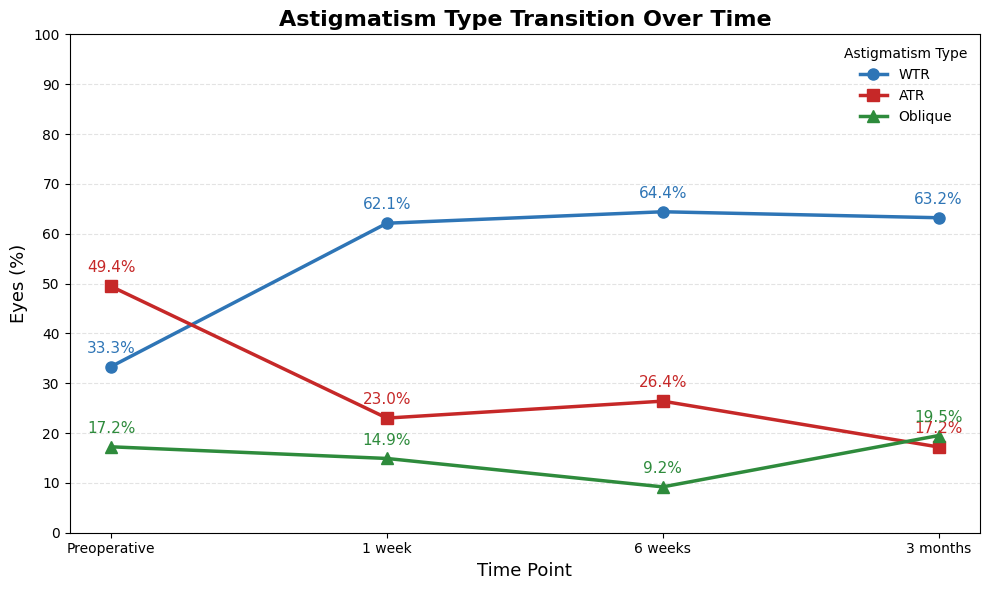

In [ ]:
import matplotlib.pyplot as plt

# Data from Thibos power-vector classification
time_points = ["Preoperative", "1 week", "6 weeks", "3 months"]

atr = [49.43, 23.0, 26.4, 17.2]
wtr = [33.33, 62.1, 64.4, 63.2]
oblique = [17.24, 14.9, 9.2, 19.5]

# Create figure
plt.figure(figsize=(10, 6))

# Plot lines
plt.plot(
    time_points, wtr,
    marker="o", linewidth=2.5, markersize=8,
    color="#2E75B6", label="WTR"
)

plt.plot(
    time_points, atr,
    marker="s", linewidth=2.5, markersize=8,
    color="#C62828", label="ATR"
)

plt.plot(
    time_points, oblique,
    marker="^", linewidth=2.5, markersize=8,
    color="#2E8B3C", label="Oblique"
)

# Add percentage labels
for i, value in enumerate(wtr):
    plt.annotate(
        f"{value:.1f}%",
        (i, value),
        xytext=(0, 10),
        textcoords="offset points",
        ha="center",
        color="#2E75B6",
        fontsize=11
    )

for i, value in enumerate(atr):
    plt.annotate(
        f"{value:.1f}%",
        (i, value),
        xytext=(0, 10),
        textcoords="offset points",
        ha="center",
        color="#C62828",
        fontsize=11
    )

for i, value in enumerate(oblique):
    plt.annotate(
        f"{value:.1f}%",
        (i, value),
        xytext=(0, 10),
        textcoords="offset points",
        ha="center",
        color="#2E8B3C",
        fontsize=11
    )

# Titles and labels
plt.title(
    "Astigmatism Type Transition Over Time",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Time Point", fontsize=13)
plt.ylabel("Eyes (%)", fontsize=13)

# Y-axis
plt.ylim(0, 100)
plt.yticks(range(0, 101, 10))

# Grid
plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.35
)

# Legend
plt.legend(
    title="Astigmatism Type",
    loc="upper right",
    frameon=False
)

# Clean layout
plt.tight_layout()

# Save high-resolution figure
plt.savefig(
    "astigmatism_type_transition.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
# Check the classification variables
cols = [
    'Preop_vectorastigmatism',
    'Postop_1wk_Astigmatism_Type',
    'Postop_6wk_Astigmatism_Type',
    'Postop_3mth_Astigmatism_Type'
]

for col in cols:
    print(f"\n{col}")
    print(sorted_data[col].value_counts(dropna=False))




Preop_vectorastigmatism
Preop_vectorastigmatism
ATR        43
WTR        29
Oblique    15
Name: count, dtype: int64

Postop_1wk_Astigmatism_Type
Postop_1wk_Astigmatism_Type
WTR        54
ATR        20
Oblique    13
Name: count, dtype: int64

Postop_6wk_Astigmatism_Type
Postop_6wk_Astigmatism_Type
WTR        56
ATR        23
Oblique     8
Name: count, dtype: int64

Postop_3mth_Astigmatism_Type
Postop_3mth_Astigmatism_Type
WTR        55
Oblique    17
ATR        15
Name: count, dtype: int64


In [ ]:
!pip install -q statsmodels


In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import cohen_kappa_score
from statsmodels.stats.contingency_tables import mcnemar

# --- Preop vs 1 week ---
pairs_preop_1wk = sorted_data[
    ['Preop_vectorastigmatism', 'Postop_1wk_Astigmatism_Type']
].dropna().copy()

kappa_preop_1wk = cohen_kappa_score(
    pairs_preop_1wk['Preop_vectorastigmatism'],
    pairs_preop_1wk['Postop_1wk_Astigmatism_Type']
)
contingency_table_preop_1wk = pd.crosstab(
    pairs_preop_1wk['Preop_vectorastigmatism'],
    pairs_preop_1wk['Postop_1wk_Astigmatism_Type']
)
result_mcnemar_preop_1wk = mcnemar(contingency_table_preop_1wk, exact=False)
p_preop_1wk_mh = result_mcnemar_preop_1wk.pvalue

# --- Preop vs 6 weeks ---
pairs_preop_6wk = sorted_data[
    ['Preop_vectorastigmatism', 'Postop_6wk_Astigmatism_Type']
].dropna().copy()

kappa_preop_6wk = cohen_kappa_score(
    pairs_preop_6wk['Preop_vectorastigmatism'],
    pairs_preop_6wk['Postop_6wk_Astigmatism_Type']
)
contingency_table_preop_6wk = pd.crosstab(
    pairs_preop_6wk['Preop_vectorastigmatism'],
    pairs_preop_6wk['Postop_6wk_Astigmatism_Type']
)
result_mcnemar_preop_6wk = mcnemar(contingency_table_preop_6wk, exact=False)
p_preop_6wk_mh = result_mcnemar_preop_6wk.pvalue

# --- Preop vs 3 months ---
pairs_preop_3mth = sorted_data[
    ['Preop_vectorastigmatism', 'Postop_3mth_Astigmatism_Type']
].dropna().copy()

kappa_preop_3mth = cohen_kappa_score(
    pairs_preop_3mth['Preop_vectorastigmatism'],
    pairs_preop_3mth['Postop_3mth_Astigmatism_Type']
)
contingency_table_preop_3mth = pd.crosstab(
    pairs_preop_3mth['Preop_vectorastigmatism'],
    pairs_preop_3mth['Postop_3mth_Astigmatism_Type']
)
result_mcnemar_preop_3mth = mcnemar(contingency_table_preop_3mth, exact=False)
p_preop_3mth_mh = result_mcnemar_preop_3mth.pvalue

# --- 6 weeks vs 3 months ---
pairs_6wk_3mth = sorted_data[
    ['Postop_6wk_Astigmatism_Type', 'Postop_3mth_Astigmatism_Type']
].dropna().copy()

kappa_6wk_3mth = cohen_kappa_score(
    pairs_6wk_3mth['Postop_6wk_Astigmatism_Type'],
    pairs_6wk_3mth['Postop_3mth_Astigmatism_Type']
)
contingency_table_6wk_3mth = pd.crosstab(
    pairs_6wk_3mth['Postop_6wk_Astigmatism_Type'],
    pairs_6wk_3mth['Postop_3mth_Astigmatism_Type']
)
result_mcnemar_6wk_3mth = mcnemar(contingency_table_6wk_3mth, exact=False)
p_6wk_3mth_mh = result_mcnemar_6wk_3mth.pvalue


final_summary = pd.DataFrame({
    'Comparison': [
        'Preop vs 1 week',
        'Preop vs 6 weeks',
        'Preop vs 3 months',
        '6 weeks vs 3 months'
    ],
    'N': [
        len(pairs_preop_1wk),
        len(pairs_preop_6wk),
        len(pairs_preop_3mth),
        len(pairs_6wk_3mth)
    ],
    "Cohen's kappa": [
        round(kappa_preop_1wk, 3),
        round(kappa_preop_6wk, 3),
        round(kappa_preop_3mth, 3),
        round(kappa_6wk_3mth, 3)
    ],
    'Marginal homogeneity p-value': [
        p_preop_1wk_mh,
        p_preop_6wk_mh,
        p_preop_3mth_mh,
        p_6wk_3mth_mh
    ]
})

final_summary['Significant'] = np.where(
    final_summary['Marginal homogeneity p-value'] < 0.05,
    'Yes',
    'No'
)

display(final_summary)

,Comparison,N,Cohen's kappa,Marginal homogeneity p-value,Significant
0,Preop vs 1 week,87,-0.020,0.449692,No
1,Preop vs 6 weeks,87,-0.115,1.000000,No
2,Preop vs 3 months,87,-0.046,0.045500,Yes
3,6 weeks vs 3 months,87,0.392,0.045500,Yes


Astigmatism distribution:


,Time,Astigmatism,Count,Percentage
0,Preoperative,WTR,29,33.333333
1,Preoperative,ATR,43,49.425287
2,Preoperative,Oblique,15,17.241379
3,1 week,WTR,54,62.068966
4,1 week,ATR,20,22.988506
5,1 week,Oblique,13,14.942529
6,6 weeks,WTR,56,64.367816
7,6 weeks,ATR,23,26.436782
8,6 weeks,Oblique,8,9.195402
9,3 months,WTR,55,63.218391



Percentage table:


Astigmatism,ATR,Oblique,WTR
Time,,,
Preoperative,49.4,17.2,33.3
1 week,23.0,14.9,62.1
6 weeks,26.4,9.2,64.4
3 months,17.2,19.5,63.2


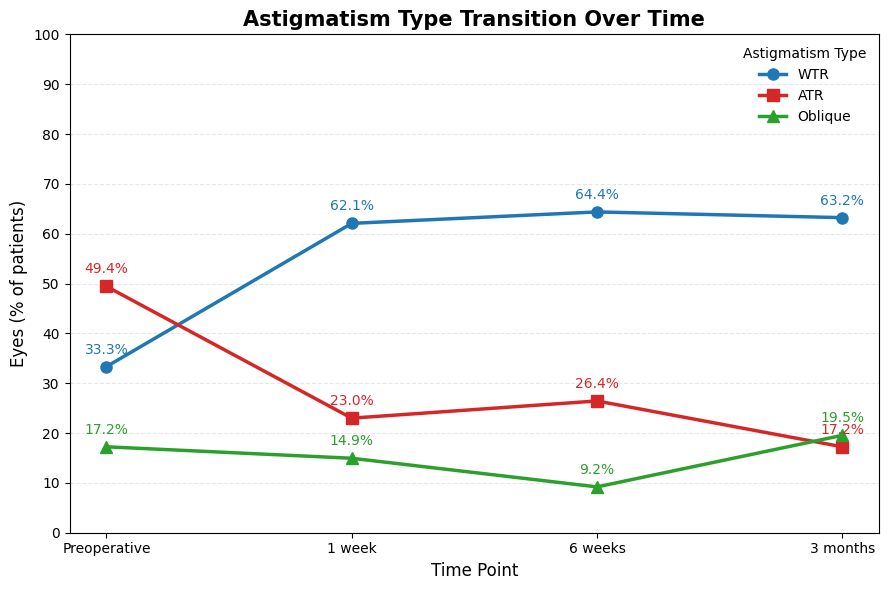

In [ ]:
# ============================================================
# LINE GRAPH: ASTIGMATISM TYPE TRANSITION
# Preoperative → 6 weeks → 3 months
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# STEP 1: Define astigmatism classification function
# ------------------------------------------------------------
def classify_astigmatism(axis):
    """
    Classification based on cylinder axis:
    ATR      = 0–30° or 150–180°
    WTR      = 60–120°
    Oblique  = 30–60° or 120–150°
    """

    if pd.isna(axis):
        return np.nan

    # Normalize axis to 0–180
    axis = float(axis) % 180

    if axis <= 30 or axis >= 150:
        return "ATR"
    elif 60 <= axis <= 120:
        return "WTR"
    else:
        return "Oblique"


# ------------------------------------------------------------
# STEP 2: Create astigmatism-type variables
# ------------------------------------------------------------

sorted_data["Preop_vectorsastigmatism"] = sorted_data["PreopA1"].apply(
    classify_astigmatism
)
sorted_data["Postop_1wk_Astigmatism_Type"] = sorted_data["Axis1wk_minus"].apply(
    classify_astigmatism
)

sorted_data["Postop_6wk_Astigmatism_Type"] = sorted_data["Axis6wk_minus"].apply(
    classify_astigmatism
)

sorted_data["Postop_3mth_Astigmatism_Type"] = sorted_data["Axis3mth_minus"].apply(
    classify_astigmatism
)


# ------------------------------------------------------------
# STEP 3: Calculate percentages at each time point
# ------------------------------------------------------------

categories = ["WTR", "ATR", "Oblique"]

time_points = {
    "Preoperative": "Preop_vectorastigmatism",
    "1 week": "Postop_1wk_Astigmatism_Type",
    "6 weeks": "Postop_6wk_Astigmatism_Type",
    "3 months": "Postop_3mth_Astigmatism_Type"
}

percentage_data = []

for time, column in time_points.items():

    counts = sorted_data[column].value_counts()

    total = sorted_data[column].notna().sum()

    for category in categories:
        count = counts.get(category, 0)

        percentage = (count / total) * 100 if total > 0 else np.nan

        percentage_data.append({
            "Time": time,
            "Astigmatism": category,
            "Count": count,
            "Percentage": percentage
        })

summary = pd.DataFrame(percentage_data)

print("Astigmatism distribution:")
display(summary)


# ------------------------------------------------------------
# STEP 4: Prepare data for plotting
# ------------------------------------------------------------

plot_data = summary.pivot(
    index="Time",
    columns="Astigmatism",
    values="Percentage"
)

plot_data = plot_data.loc[
    ["Preoperative", "1 week", "6 weeks", "3 months"]
]

print("\nPercentage table:")
display(plot_data.round(1))


# ------------------------------------------------------------
# STEP 5: Create line graph
# ------------------------------------------------------------

plt.figure(figsize=(9, 6))

colors = {
    "WTR": "#1f77b4",
    "ATR": "#d62728",
    "Oblique": "#2ca02c"
}

markers = {
    "WTR": "o",
    "ATR": "s",
    "Oblique": "^"
}

for category in categories:

    plt.plot(
        plot_data.index,
        plot_data[category],
        marker=markers[category],
        linewidth=2.5,
        markersize=8,
        color=colors[category],
        label=category
    )

    # Add percentage labels
    for x, y in zip(
        plot_data.index,
        plot_data[category]
    ):
        plt.text(
            x,
            y + 2,
            f"{y:.1f}%",
            ha="center",
            va="bottom",
            fontsize=10,
            color=colors[category]
        )


# ------------------------------------------------------------
# STEP 6: Format graph
# ------------------------------------------------------------

plt.title(
    "Astigmatism Type Transition Over Time",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel(
    "Time Point",
    fontsize=12
)

plt.ylabel(
    "Eyes (% of patients)",
    fontsize=12
)

plt.ylim(0, 100)

plt.yticks(
    np.arange(0, 101, 10)
)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

plt.legend(
    title="Astigmatism Type",
    frameon=False
)

plt.tight_layout()

plt.show()

In [ ]:
# ============================================================
# LINE GRAPH OF ASTIGMATIC VECTORS
# J0, J45 and J
# Preoperative → 1 week to 6 weeks → 3 months
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# STEP 1: Define variables
# ------------------------------------------------------------

time_points = ["Preoperative", "1 week","6 weeks", "3 months"]

j0_cols = ["Preop_J0", "J0_1wk", "J0_6wk", "J0_3mth"]
j45_cols = ["Preop_J45", "J45_1wk", "J45_6wk", "J45_3mth"]
j_cols = ["Preop_J", "J_1wk", "J_6wk", "J_3mth"]


# ------------------------------------------------------------
# STEP 2: Calculate mean and SD
# ------------------------------------------------------------

summary = pd.DataFrame({
    "Time": time_points,

    "J0_Mean": [
        sorted_data[col].mean() for col in j0_cols
    ],

    "J0_SD": [
        sorted_data[col].std() for col in j0_cols
    ],

    "J0_Median": [
        sorted_data[col].median() for col in j0_cols
    ],

    "J45_Mean": [
        sorted_data[col].mean() for col in j45_cols
    ],

    "J45_SD": [
        sorted_data[col].std() for col in j45_cols
    ],

    "J45_Median": [
        sorted_data[col].median() for col in j45_cols
    ],

    "J_Mean": [
        sorted_data[col].mean() for col in j_cols
    ],

    "J_SD": [
        sorted_data[col].std() for col in j_cols
    ],
    "J_Median": [
        sorted_data[col].median() for col in j_cols
    ]

})

display(summary.round(3))


,Time,J0_Mean,J0_SD,J0_Median,J45_Mean,J45_SD,J45_Median,J_Mean,J_SD,J_Median
0,Preoperative,-0.072,0.416,-0.086,-0.008,0.320,0.000,0.432,0.302,0.375
1,1 week,0.511,0.930,0.470,-0.056,0.572,-0.065,1.024,0.630,1.000
2,6 weeks,0.408,0.736,0.369,-0.068,0.585,-0.000,0.856,0.561,0.750
3,3 months,0.335,0.603,0.325,0.015,0.566,-0.000,0.740,0.493,0.625


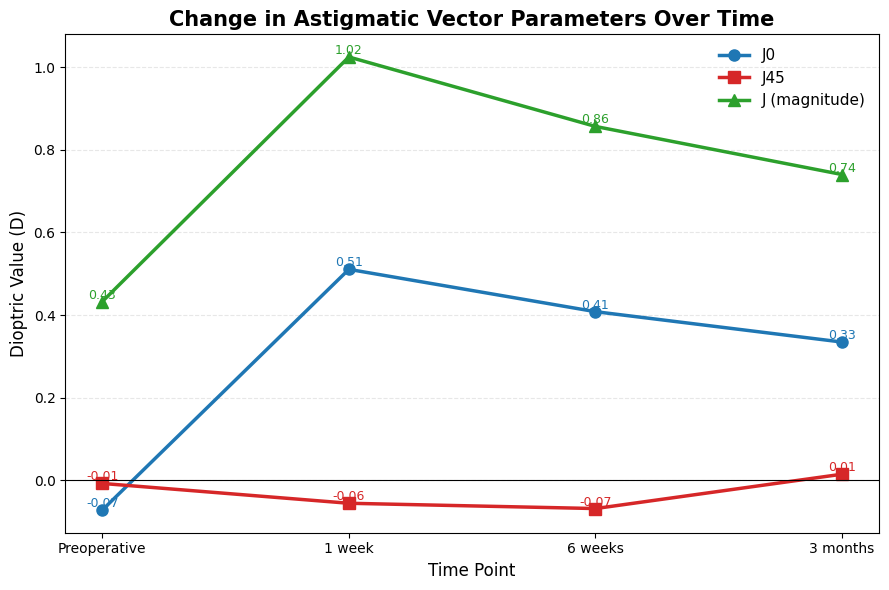

In [ ]:
# ============================================================
# STEP 3: LINE GRAPH
# ============================================================

plt.figure(figsize=(9, 6))

# J0
plt.plot(
    summary["Time"],
    summary["J0_Mean"],
    marker="o",
    linewidth=2.5,
    markersize=8,
    color="#1f77b4",
    label="J0"
)

# J45
plt.plot(
    summary["Time"],
    summary["J45_Mean"],
    marker="s",
    linewidth=2.5,
    markersize=8,
    color="#d62728",
    label="J45"
)

# J
plt.plot(
    summary["Time"],
    summary["J_Mean"],
    marker="^",
    linewidth=2.5,
    markersize=8,
    color="#2ca02c",
    label="J (magnitude)"
)


# ------------------------------------------------------------
# STEP 4: Add mean value labels
# ------------------------------------------------------------

for i in range(len(summary)):

    plt.text(
        i,
        summary.loc[i, "J0_Mean"],
        f'{summary.loc[i, "J0_Mean"]:.2f}',
        ha="center",
        va="bottom",
        fontsize=9,
        color="#1f77b4"
    )

    plt.text(
        i,
        summary.loc[i, "J45_Mean"],
        f'{summary.loc[i, "J45_Mean"]:.2f}',
        ha="center",
        va="bottom",
        fontsize=9,
        color="#d62728"
    )

    plt.text(
        i,
        summary.loc[i, "J_Mean"],
        f'{summary.loc[i, "J_Mean"]:.2f}',
        ha="center",
        va="bottom",
        fontsize=9,
        color="#2ca02c"
    )


# ------------------------------------------------------------
# STEP 5: Format graph
# ------------------------------------------------------------

plt.axhline(
    y=0,
    color="black",
    linewidth=0.8,
    linestyle="-"
)

plt.title(
    "Change in Astigmatic Vector Parameters Over Time",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel(
    "Time Point",
    fontsize=12
)

plt.ylabel(
    "Dioptric Value (D)",
    fontsize=12
)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

plt.legend(
    frameon=False,
    fontsize=11
)

plt.tight_layout()

plt.show()


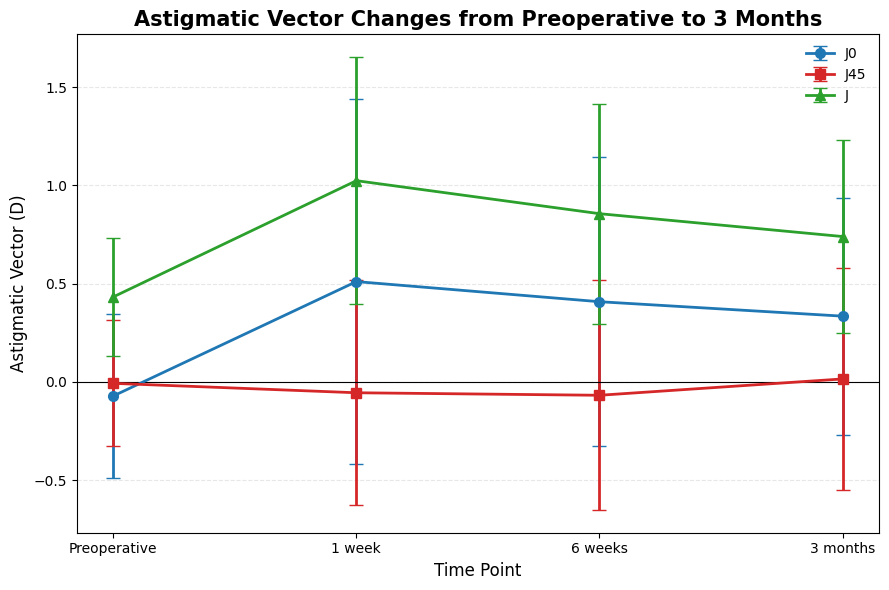

In [ ]:
# ============================================================
# MEAN ± SD LINE GRAPH
# ============================================================

plt.figure(figsize=(9, 6))

x = np.arange(len(summary))

# J0
plt.errorbar(
    x,
    summary["J0_Mean"],
    yerr=summary["J0_SD"],
    marker="o",
    linewidth=2,
    markersize=7,
    capsize=5,
    color="#1f77b4",
    label="J0"
)

# J45
plt.errorbar(
    x,
    summary["J45_Mean"],
    yerr=summary["J45_SD"],
    marker="s",
    linewidth=2,
    markersize=7,
    capsize=5,
    color="#d62728",
    label="J45"
)

# J
plt.errorbar(
    x,
    summary["J_Mean"],
    yerr=summary["J_SD"],
    marker="^",
    linewidth=2,
    markersize=7,
    capsize=5,
    color="#2ca02c",
    label="J"
)

plt.axhline(
    0,
    color="black",
    linewidth=0.8
)

plt.xticks(
    x,
    summary["Time"]
)

plt.xlabel(
    "Time Point",
    fontsize=12
)

plt.ylabel(
    "Astigmatic Vector (D)",
    fontsize=12
)

plt.title(
    "Astigmatic Vector Changes from Preoperative to 3 Months",
    fontsize=15,
    fontweight="bold"
)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

plt.legend(
    frameon=False
)

plt.tight_layout()

plt.show()



ASTIGMATISM TYPE DISTRIBUTION


,Time,Astigmatism,Count,Percentage
0,Preoperative,ATR,43,49.43
1,Preoperative,WTR,29,33.33
2,Preoperative,Oblique,15,17.24
3,1 week,ATR,20,22.99
4,1 week,WTR,54,62.07
5,1 week,Oblique,13,14.94
6,6 weeks,ATR,23,26.44
7,6 weeks,WTR,56,64.37
8,6 weeks,Oblique,8,9.20
9,3 months,ATR,15,17.24



J0 / J45 SUMMARY


,Time,J0 Mean,J0 SD,J0 Median,J45 Mean,J45 SD,J45 Median
0,Preoperative,-0.072,0.416,-0.086,-0.008,0.320,0.000
1,1 week,0.511,0.930,0.470,-0.056,0.572,-0.065
2,6 weeks,0.408,0.736,0.369,-0.068,0.585,-0.000
3,3 months,0.335,0.603,0.325,0.015,0.566,-0.000



J0 DIRECTION CHECK

Preoperative
ATR: n=43, Mean J0=-0.381 D, Median J0=-0.375 D
WTR: n=29, Mean J0=0.353 D, Median J0=0.246 D
Oblique: n=15, Mean J0=-0.009 D, Median J0=-0.022 D

1 week
ATR: n=20, Mean J0=-0.679 D, Median J0=-0.558 D
WTR: n=54, Mean J0=1.080 D, Median J0=1.091 D
Oblique: n=13, Mean J0=-0.027 D, Median J0=-0.065 D

6 weeks
ATR: n=23, Mean J0=-0.479 D, Median J0=-0.325 D
WTR: n=56, Mean J0=0.810 D, Median J0=0.700 D
Oblique: n=8, Mean J0=0.148 D, Median J0=0.075 D

3 months
ATR: n=15, Mean J0=-0.553 D, Median J0=-0.575 D
WTR: n=55, Mean J0=0.666 D, Median J0=0.575 D
Oblique: n=17, Mean J0=0.044 D, Median J0=0.086 D


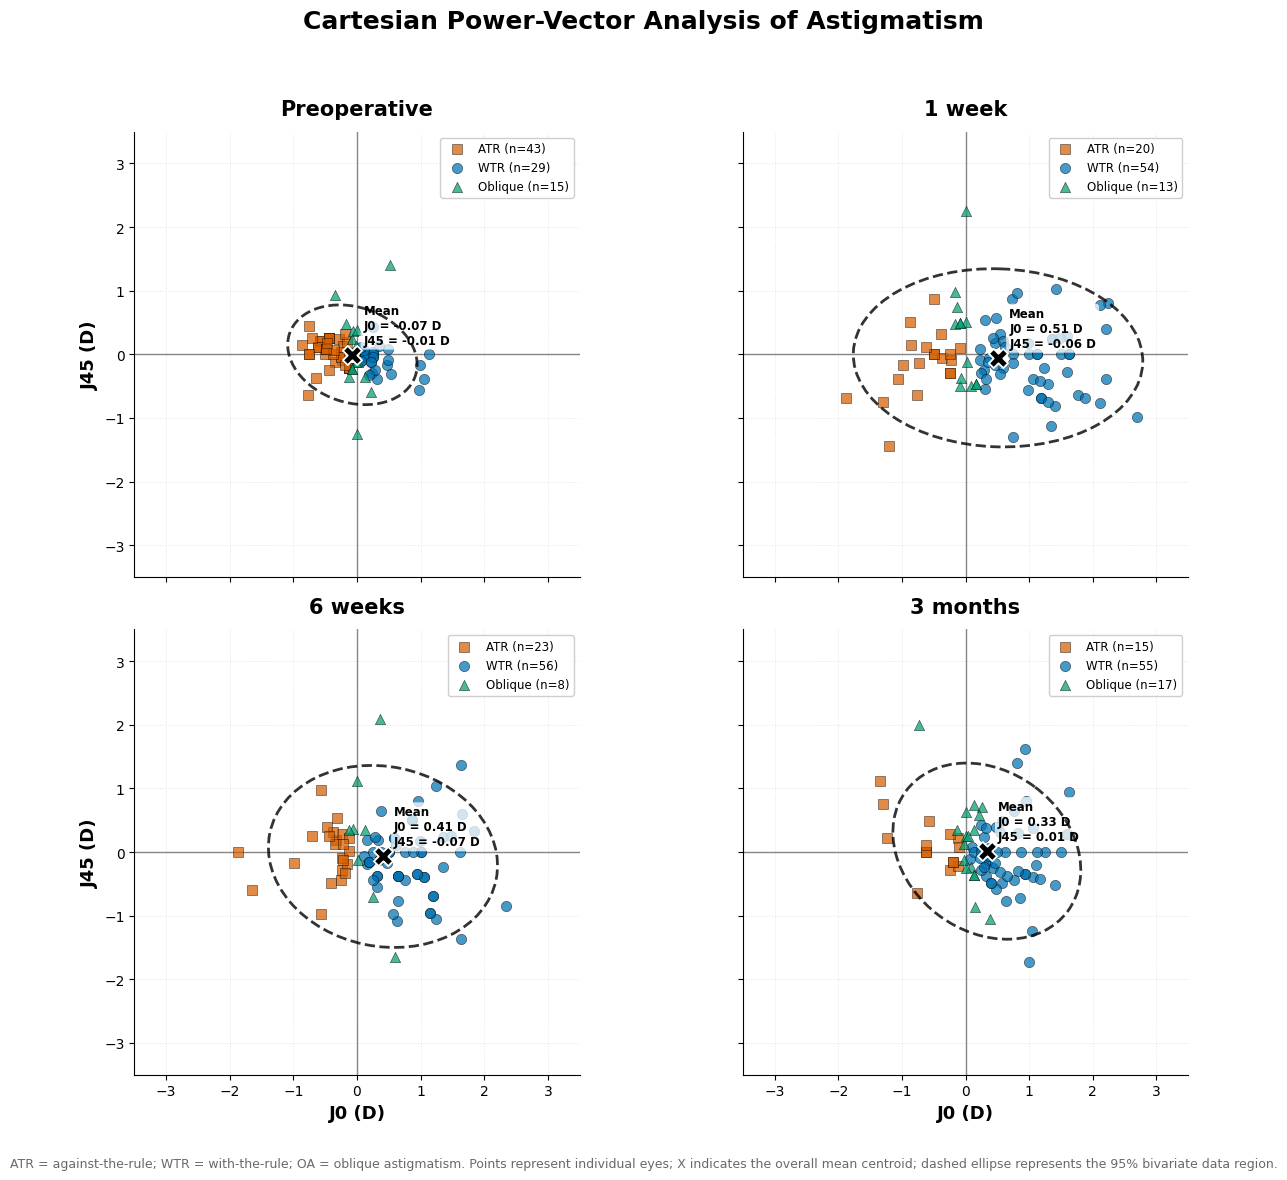

In [ ]:
# ============================================================
# PUBLICATION-QUALITY 4-PANEL CARTESIAN PLOTS
# THIBOS POWER-VECTOR ANALYSIS
#
# Preoperative → 1 week → 6 weeks → 3 months
#
# X-axis = J0 (D)
# Y-axis = J45 (D)
#
# WTR  = positive J0 side
# ATR  = negative J0 side
# OA   = oblique astigmatism
#
# Classification is based on the original minus-cylinder axis.
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
from scipy.stats import chi2


# ============================================================
# 1. TIME POINTS AND VARIABLES
# ============================================================

timepoints = {
    "Preoperative": {
        "J0": "Preop_J0",
        "J45": "Preop_J45",
        "Axis": "Preop_vector_axis"
    },

    "1 week": {
        "J0": "J0_1wk",
        "J45": "J45_1wk",
        "Axis": "Axis1wk_minus"
    },

    "6 weeks": {
        "J0": "J0_6wk",
        "J45": "J45_6wk",
        "Axis": "Axis6wk_minus"
    },

    "3 months": {
        "J0": "J0_3mth",
        "J45": "J45_3mth",
        "Axis": "Axis3mth_minus"
    }
}


# ============================================================
# 2. ASTIGMATISM CLASSIFICATION
# ============================================================

def classify_astigmatism(axis):

    if pd.isna(axis):
        return np.nan

    axis = float(axis) % 180

    # ATR = 0–30° or 150–180°
    if axis <= 30 or axis >= 150:
        return "ATR"

    # WTR = 60–120°
    elif axis >= 60 and axis <= 120:
        return "WTR"

    # Oblique = 30–60° or 120–150°
    else:
        return "Oblique"


# ============================================================
# 3. COLORS
# ============================================================

colors = {
    "ATR": "#D55E00",       # Orange/red
    "WTR": "#0072B2",       # Blue
    "Oblique": "#009E73"    # Green
}


markers = {
    "ATR": "s",
    "WTR": "o",
    "Oblique": "^"
}


# ============================================================
# 4. CREATE SUMMARY TABLE
# ============================================================

categories = [
    "ATR",
    "WTR",
    "Oblique"
]

summary_data = []


for time_label, cols in timepoints.items():

    axis_data = sorted_data[
        cols["Axis"]
    ].dropna()

    total = len(axis_data)

    classified = axis_data.apply(
        classify_astigmatism
    )

    counts = classified.value_counts()

    for category in categories:

        count = counts.get(
            category,
            0
        )

        percentage = (
            count / total * 100
            if total > 0
            else np.nan
        )

        summary_data.append({
            "Time": time_label,
            "Astigmatism": category,
            "Count": count,
            "Percentage": percentage
        })


summary = pd.DataFrame(
    summary_data
)


# ============================================================
# 5. DISPLAY CLASSIFICATION TABLE
# ============================================================

print("\nASTIGMATISM TYPE DISTRIBUTION")
print("=" * 70)

display(
    summary.round(2)
)


# ============================================================
# 6. J0 / J45 SUMMARY
# ============================================================

vector_summary = []

for time_label, cols in timepoints.items():

    j0 = sorted_data[
        cols["J0"]
    ].dropna()

    j45 = sorted_data[
        cols["J45"]
    ].dropna()

    vector_summary.append({

        "Time": time_label,

        "J0 Mean": j0.mean(),
        "J0 SD": j0.std(),
        "J0 Median": j0.median(),

        "J45 Mean": j45.mean(),
        "J45 SD": j45.std(),
        "J45 Median": j45.median(),

    })


vector_summary = pd.DataFrame(
    vector_summary
)


print("\nJ0 / J45 SUMMARY")
print("=" * 70)

display(
    vector_summary.round(3)
)


# ============================================================
# 7. CHECK WTR / ATR DIRECTION
# ============================================================
#
# Expected convention:
#
# WTR → positive J0
# ATR → negative J0
#
# This is only a diagnostic check.
# It does NOT alter the data.
# ============================================================

print("\nJ0 DIRECTION CHECK")
print("=" * 70)

for time_label, cols in timepoints.items():

    temp = sorted_data[
        [
            cols["J0"],
            cols["Axis"]
        ]
    ].dropna().copy()

    temp.columns = [
        "J0",
        "Axis"
    ]

    temp["Type"] = temp["Axis"].apply(
        classify_astigmatism
    )

    print(f"\n{time_label}")

    for category in [
        "ATR",
        "WTR",
        "Oblique"
    ]:

        values = temp.loc[
            temp["Type"] == category,
            "J0"
        ]

        if len(values) > 0:

            print(
                f"{category}: "
                f"n={len(values)}, "
                f"Mean J0={values.mean():.3f} D, "
                f"Median J0={values.median():.3f} D"
            )


# ============================================================
# 8. CALCULATE COMMON AXIS LIMITS
# ============================================================

all_j0 = []
all_j45 = []

for cols in timepoints.values():

    all_j0.extend(
        sorted_data[
            cols["J0"]
        ].dropna().values
    )

    all_j45.extend(
        sorted_data[
            cols["J45"]
        ].dropna().values
    )


max_abs = max(
    np.max(np.abs(all_j0)),
    np.max(np.abs(all_j45))
)


# Round to convenient value
limit = (
    np.ceil(max_abs * 2) / 2
    + 0.5
)


# ============================================================
# 9. FUNCTION FOR 95% BIVARIATE DATA ELLIPSE
# ============================================================

def add_data_ellipse(
    ax,
    x,
    y,
    color="black"
):

    if len(x) < 3:
        return

    data = np.column_stack(
        [x, y]
    )

    # Mean
    mean = np.mean(
        data,
        axis=0
    )

    # Covariance
    covariance = np.cov(
        data,
        rowvar=False
    )

    # Eigenvalues/eigenvectors
    eigenvalues, eigenvectors = np.linalg.eigh(
        covariance
    )

    # Sort from largest to smallest
    order = eigenvalues.argsort()[::-1]

    eigenvalues = eigenvalues[order]
    eigenvectors = eigenvectors[:, order]

    # Avoid negative numerical values
    eigenvalues = np.maximum(
        eigenvalues,
        0
    )

    # 95% bivariate region
    chi_value = chi2.ppf(
        0.95,
        df=2
    )

    width = (
        2 *
        np.sqrt(
            eigenvalues[0] *
            chi_value
        )
    )

    height = (
        2 *
        np.sqrt(
            eigenvalues[1] *
            chi_value
        )
    )

    # Ellipse rotation
    angle = np.degrees(
        np.arctan2(
            eigenvectors[1, 0],
            eigenvectors[0, 0]
        )
    )

    ellipse = Ellipse(
        xy=mean,
        width=width,
        height=height,
        angle=angle,
        facecolor="none",
        edgecolor=color,
        linewidth=2,
        linestyle="--",
        alpha=0.8,
        zorder=4
    )

    ax.add_patch(
        ellipse
    )


# ============================================================
# 10. CREATE 4-PANEL FIGURE
# ============================================================

fig, axes = plt.subplots(
    2,
    2,
    figsize=(13, 12),
    sharex=True,
    sharey=True
)

axes = axes.flatten()


# ============================================================
# 11. GENERATE EACH PANEL
# ============================================================

for ax, (time_label, cols) in zip(
    axes,
    timepoints.items()
):

    # --------------------------------------------------------
    # Extract J0, J45 and axis
    # --------------------------------------------------------

    temp = sorted_data[
        [
            cols["J0"],
            cols["J45"],
            cols["Axis"]
        ]
    ].dropna().copy()

    temp.columns = [
        "J0",
        "J45",
        "Axis"
    ]


    # --------------------------------------------------------
    # Classify using original minus-cylinder axis
    # --------------------------------------------------------

    temp["Type"] = temp["Axis"].apply(
        classify_astigmatism
    )


    # ========================================================
    # PLOT EACH ASTIGMATISM TYPE
    # ========================================================

    for category in [
        "ATR",
        "WTR",
        "Oblique"
    ]:

        subset = temp[
            temp["Type"] == category
        ]

        ax.scatter(
            subset["J0"],
            subset["J45"],

            s=55,

            color=colors[category],

            marker=markers[category],

            alpha=0.72,

            edgecolor="black",

            linewidth=0.4,

            label=(
                f"{category} "
                f"(n={len(subset)})"
            ),

            zorder=3
        )


    # ========================================================
    # OVERALL MEAN CENTROID
    # ========================================================

    mean_j0 = temp["J0"].mean()
    mean_j45 = temp["J45"].mean()

    ax.scatter(
        mean_j0,
        mean_j45,

        marker="X",

        s=190,

        color="black",

        edgecolor="white",

        linewidth=1.3,

        zorder=10
    )


    # Mean label
    ax.annotate(
        f"Mean\n"
        f"J0 = {mean_j0:.2f} D\n"
        f"J45 = {mean_j45:.2f} D",

        xy=(
            mean_j0,
            mean_j45
        ),

        xytext=(
            8,
            8
        ),

        textcoords="offset points",

        fontsize=8.5,

        fontweight="bold",

        bbox=dict(
            boxstyle="round,pad=0.25",
            facecolor="white",
            edgecolor="none",
            alpha=0.75
        )
    )


    # ========================================================
    # 95% DATA ELLIPSE
    # ========================================================

    add_data_ellipse(
        ax,
        temp["J0"].values,
        temp["J45"].values
    )


    # ========================================================
    # ZERO REFERENCE LINES
    # ========================================================

    ax.axhline(
        0,
        color="gray",
        linewidth=1.0,
        zorder=1
    )

    ax.axvline(
        0,
        color="gray",
        linewidth=1.0,
        zorder=1
    )


    # ========================================================
    # PANEL FORMATTING
    # ========================================================

    ax.set_title(
        time_label,
        fontsize=15,
        fontweight="bold",
        pad=12
    )

    ax.set_xlim(
        -limit,
        limit
    )

    ax.set_ylim(
        -limit,
        limit
    )

    ax.set_aspect(
        "equal",
        adjustable="box"
    )

    ax.grid(
        True,
        linestyle=":",
        linewidth=0.7,
        alpha=0.35
    )

    ax.tick_params(
        labelsize=10
    )

    # Clean top/right borders
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)


    # ========================================================
    # LEGEND
    # ========================================================

    ax.legend(
        fontsize=8.5,
        loc="upper right",
        frameon=True,
        framealpha=0.95
    )


# ============================================================
# 12. AXIS LABELS
# ============================================================

axes[2].set_xlabel(
    "J0 (D)",
    fontsize=13,
    fontweight="bold"
)

axes[3].set_xlabel(
    "J0 (D)",
    fontsize=13,
    fontweight="bold"
)

axes[0].set_ylabel(
    "J45 (D)",
    fontsize=13,
    fontweight="bold"
)

axes[2].set_ylabel(
    "J45 (D)",
    fontsize=13,
    fontweight="bold"
)


# ============================================================
# 13. MAIN TITLE
# ============================================================

fig.suptitle(
    "Cartesian Power-Vector Analysis of Astigmatism",
    fontsize=18,
    fontweight="bold",
    y=0.98
)


# ============================================================
# 14. FOOTNOTE
# ============================================================

fig.text(
    0.5,
    0.015,

    "ATR = against-the-rule; "
    "WTR = with-the-rule; "
    "OA = oblique astigmatism. "
    "Points represent individual eyes; "
    "X indicates the overall mean centroid; "
    "dashed ellipse represents the 95% bivariate data region.",

    ha="center",

    fontsize=9,

    color="dimgray"
)


# ============================================================
# 15. FINAL LAYOUT
# ============================================================

plt.tight_layout(
    rect=[
        0,
        0.04,
        1,
        0.95
    ]
)


# ============================================================
# 16. SAVE HIGH-RESOLUTION FIGURE
# ============================================================

plt.savefig(
    "Cartesian_Power_Vector_4Panel.png",

    dpi=300,

    bbox_inches="tight",

    facecolor="white"
)


# ============================================================
# 17. DISPLAY
# ============================================================

plt.show()



ASTIGMATISM TYPE DISTRIBUTION


,Time,Astigmatism,Count,Percentage
0,Preoperative,ATR,43,49.43
1,Preoperative,WTR,29,33.33
2,Preoperative,Oblique,15,17.24
3,1 week,ATR,20,22.99
4,1 week,WTR,54,62.07
5,1 week,Oblique,13,14.94
6,6 weeks,ATR,23,26.44
7,6 weeks,WTR,56,64.37
8,6 weeks,Oblique,8,9.20
9,3 months,ATR,15,17.24


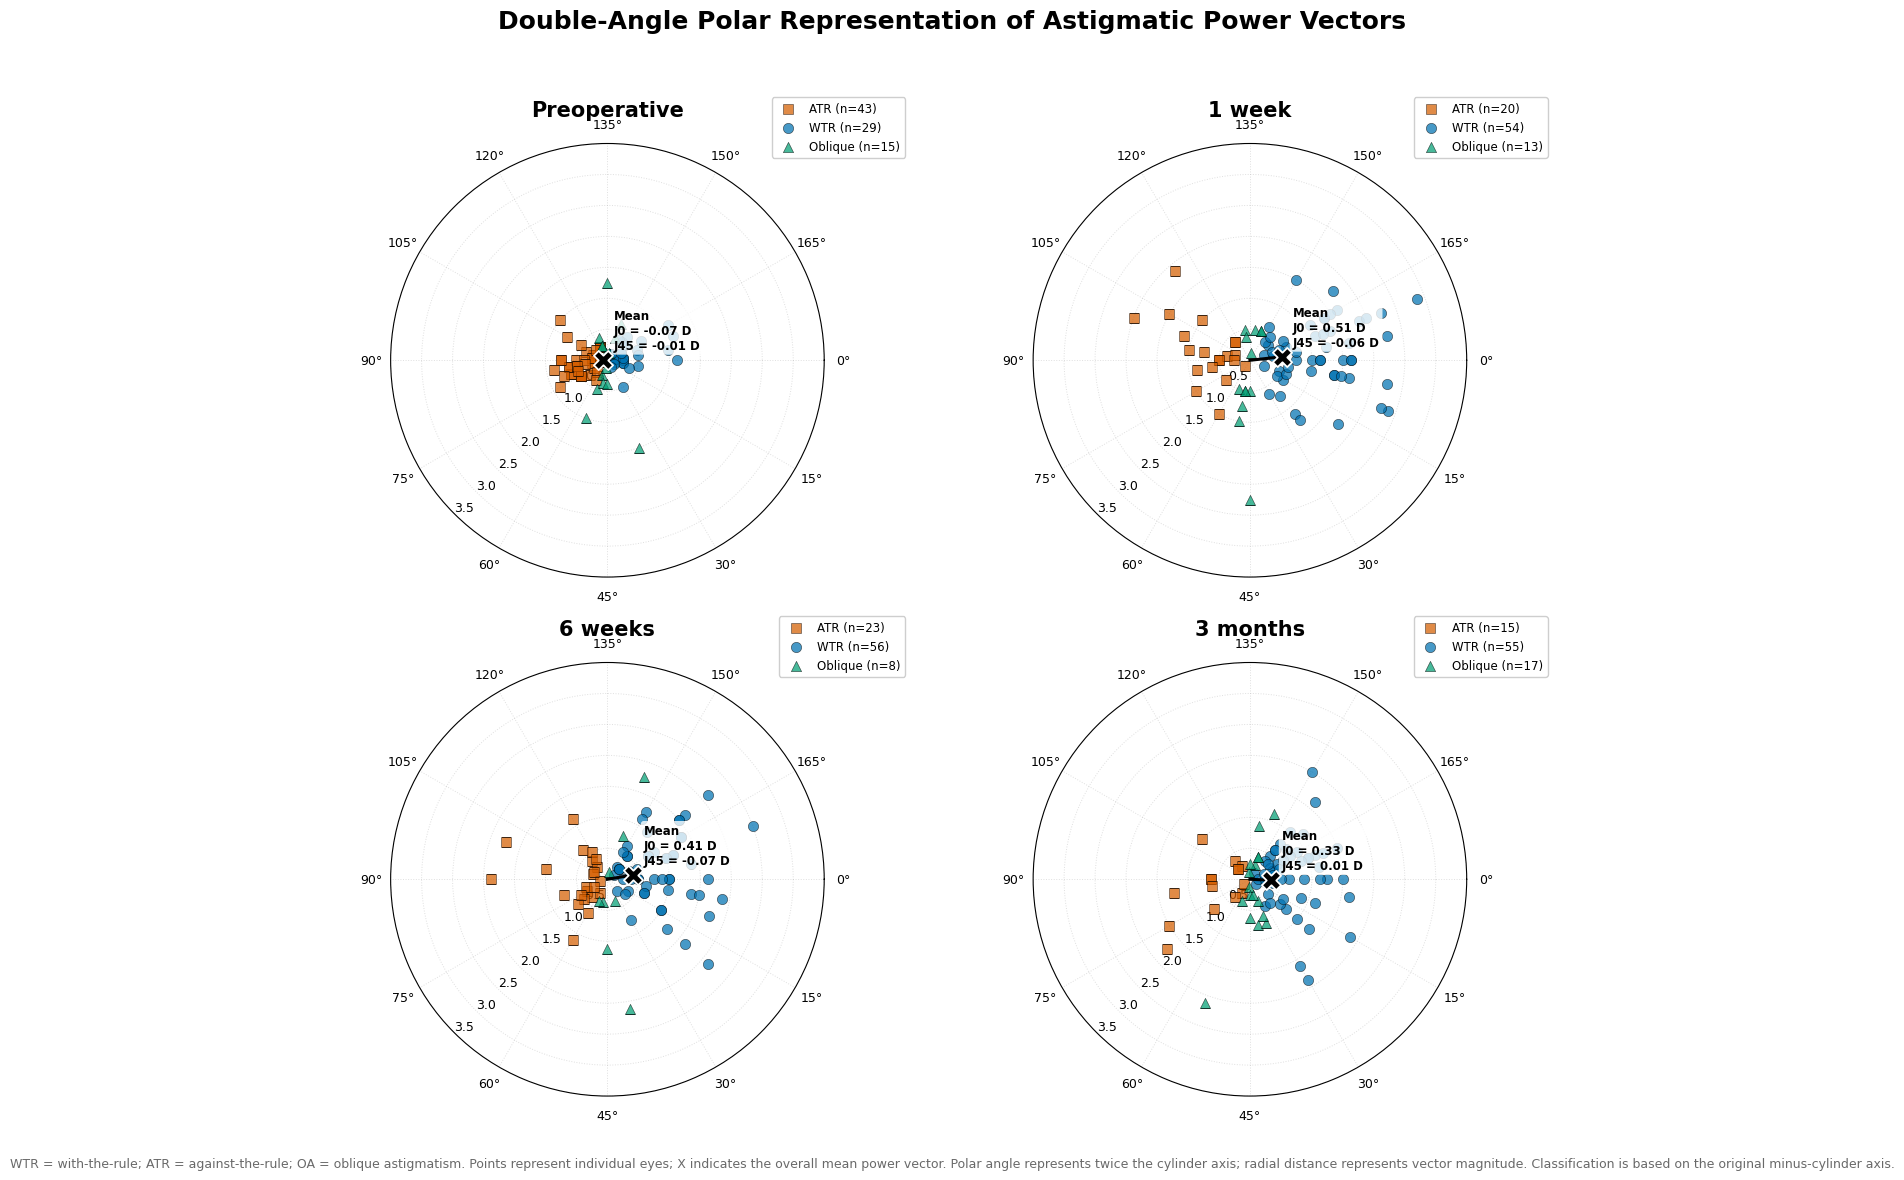

In [ ]:
# ============================================================
# PUBLICATION-QUALITY 4-PANEL DOUBLE-ANGLE POLAR PLOTS
# THIBOS POWER-VECTOR ANALYSIS
#
# Preoperative → 1 week → 6 weeks → 3 months
#
# J0 / J45 represented using double-angle polar coordinates
#
# X/Y equivalent:
#     J0  = horizontal Cartesian component
#     J45 = vertical Cartesian component
#
# Polar representation:
#     radius = sqrt(J0² + J45²)
#     theta  = atan2(J45, J0)
#
# ============================================================
# ASTIGMATISM CLASSIFICATION
# ============================================================
#
# Classification is based on the ORIGINAL MINUS-CYLINDER AXIS.
#
# WTR:
#     60–120°
#     Corresponds to POSITIVE J0
#
# ATR:
#     0–30° or 150–180°
#     Corresponds to NEGATIVE J0
#
# OBLIQUE:
#     30–60° or 120–150°
#
# This classification is identical to the Cartesian plots.
# ============================================================


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# 1. TIME POINTS AND VARIABLES
# ============================================================

timepoints = {

    "Preoperative": {
        "J0": "Preop_J0",
        "J45": "Preop_J45",
        "Axis": "Preop_vector_axis"
    },

    "1 week": {
        "J0": "J0_1wk",
        "J45": "J45_1wk",
        "Axis": "Axis1wk_minus"
    },

    "6 weeks": {
        "J0": "J0_6wk",
        "J45": "J45_6wk",
        "Axis": "Axis6wk_minus"
    },

    "3 months": {
        "J0": "J0_3mth",
        "J45": "J45_3mth",
        "Axis": "Axis3mth_minus"
    }
}


# ============================================================
# 2. ASTIGMATISM CLASSIFICATION
# ============================================================
#
# IMPORTANT:
# This is the SAME classification used in the
# corrected Cartesian plots.
#
# Minus-cylinder axis:
#
#     ATR      = 0–30° or 150–180°
#     WTR      = 60–120°
#     Oblique  = 30–60° or 120–150°
#
# Relationship with J0:
#
#     WTR → positive J0
#     ATR → negative J0
# ============================================================

def classify_astigmatism(axis):

    if pd.isna(axis):
        return np.nan

    axis = float(axis) % 180

    # --------------------------------------------------------
    # ATR
    # --------------------------------------------------------
    # Minus-cylinder axis close to 0° / 180°
    # Corresponds to negative J0
    # --------------------------------------------------------

    if axis <= 30 or axis >= 150:

        return "ATR"


    # --------------------------------------------------------
    # WTR
    # --------------------------------------------------------
    # Minus-cylinder axis close to 90°
    # Corresponds to positive J0
    # --------------------------------------------------------

    elif axis >= 60 and axis <= 120:

        return "WTR"


    # --------------------------------------------------------
    # OBLIQUE
    # --------------------------------------------------------

    else:

        return "Oblique"


# ============================================================
# 3. COLORS
# ============================================================

colors = {

    "ATR": "#D55E00",       # Orange/red

    "WTR": "#0072B2",       # Blue

    "Oblique": "#009E73"    # Green
}


# ============================================================
# 4. MARKERS
# ============================================================

markers = {

    "ATR": "s",

    "WTR": "o",

    "Oblique": "^"
}


# ============================================================
# 5. CATEGORY ORDER
# ============================================================

categories = [

    "ATR",

    "WTR",

    "Oblique"
]


# ============================================================
# 6. OPTIONAL CLASSIFICATION SUMMARY
# ============================================================
#
# This is useful for checking that the polar plot has exactly
# the same WTR / ATR / Oblique counts as the Cartesian plot.
# ============================================================

summary_data = []


for time_label, cols in timepoints.items():

    axis_data = sorted_data[
        cols["Axis"]
    ].dropna()


    total = len(axis_data)


    classified = axis_data.apply(
        classify_astigmatism
    )


    counts = classified.value_counts()


    for category in categories:

        count = counts.get(
            category,
            0
        )


        percentage = (

            count / total * 100

            if total > 0

            else np.nan
        )


        summary_data.append({

            "Time": time_label,

            "Astigmatism": category,

            "Count": count,

            "Percentage": percentage
        })


summary = pd.DataFrame(
    summary_data
)


# ============================================================
# 7. DISPLAY CLASSIFICATION CHECK
# ============================================================

print("\nASTIGMATISM TYPE DISTRIBUTION")
print("=" * 70)

display(
    summary.round(2)
)


# ============================================================
# 8. CALCULATE COMMON RADIAL LIMIT
# ============================================================

all_magnitudes = []


for cols in timepoints.values():

    temp = sorted_data[

        [
            cols["J0"],
            cols["J45"]
        ]

    ].dropna()


    magnitude = np.sqrt(

        temp[cols["J0"]]**2 +

        temp[cols["J45"]]**2
    )


    all_magnitudes.extend(

        magnitude.to_numpy()
    )


# ------------------------------------------------------------
# Check that data exist
# ------------------------------------------------------------

if len(all_magnitudes) == 0:

    raise ValueError(

        "No valid J0/J45 data were found."
    )


# ------------------------------------------------------------
# Maximum vector magnitude
# ------------------------------------------------------------

max_radius = np.nanmax(

    all_magnitudes
)


# ------------------------------------------------------------
# Round upward to convenient radial limit
# ------------------------------------------------------------

radial_limit = (

    np.ceil(

        max_radius * 2

    ) / 2

    + 0.5
)


# ============================================================
# 9. CREATE 4-PANEL POLAR FIGURE
# ============================================================

fig, axes = plt.subplots(

    2,

    2,

    figsize=(13, 12),

    subplot_kw={

        "projection": "polar"
    }
)


axes = axes.flatten()


# ============================================================
# 10. GENERATE EACH PANEL
# ============================================================

for ax, (time_label, cols) in zip(

    axes,

    timepoints.items()
):


    # ========================================================
    # EXTRACT J0 / J45 / ORIGINAL MINUS-CYLINDER AXIS
    # ========================================================

    temp = sorted_data[

        [
            cols["J0"],
            cols["J45"],
            cols["Axis"]
        ]

    ].dropna().copy()


    temp.columns = [

        "J0",
        "J45",
        "Axis"
    ]


    # ========================================================
    # CLASSIFY ASTIGMATISM
    # ========================================================
    #
    # IMPORTANT:
    # Use the ORIGINAL minus-cylinder axis.
    #
    # Do NOT recalculate axis from J0/J45 for classification.
    # ========================================================

    temp["Type"] = temp[

        "Axis"

    ].apply(

        classify_astigmatism
    )


    # ========================================================
    # VECTOR MAGNITUDE
    # ========================================================

    temp["Magnitude"] = np.sqrt(

        temp["J0"]**2 +

        temp["J45"]**2
    )


    # ========================================================
    # DOUBLE-ANGLE POLAR ANGLE
    # ========================================================
    #
    # theta = atan2(J45, J0)
    #
    # The angular coordinate is the double-angle representation
    # of the astigmatic power vector.
    # ========================================================

    temp["Theta"] = np.arctan2(

        temp["J45"],

        temp["J0"]
    )


    # ========================================================
    # PLOT EACH ASTIGMATISM CATEGORY
    # ========================================================

    for category in categories:


        subset = temp[

            temp["Type"] == category

        ]


        # ----------------------------------------------------
        # Skip empty category
        # ----------------------------------------------------

        if len(subset) == 0:

            continue


        # ----------------------------------------------------
        # Scatter plot
        # ----------------------------------------------------

        ax.scatter(

            subset["Theta"],

            subset["Magnitude"],

            s=55,

            color=colors[category],

            marker=markers[category],

            alpha=0.72,

            edgecolor="black",

            linewidth=0.4,

            label=(

                f"{category} "

                f"(n={len(subset)})"
            ),

            zorder=3
        )


    # ========================================================
    # OVERALL MEAN J0 / J45
    # ========================================================

    mean_j0 = temp[

        "J0"

    ].mean()


    mean_j45 = temp[

        "J45"

    ].mean()


    # ========================================================
    # MEAN VECTOR MAGNITUDE
    # ========================================================

    mean_radius = np.sqrt(

        mean_j0**2 +

        mean_j45**2
    )


    # ========================================================
    # MEAN VECTOR ANGLE
    # ========================================================

    mean_theta = np.arctan2(

        mean_j45,

        mean_j0
    )


    # ========================================================
    # PLOT MEAN VECTOR
    # ========================================================

    ax.plot(

        [
            mean_theta,
            mean_theta
        ],

        [
            0,
            mean_radius
        ],

        color="black",

        linewidth=2.2,

        zorder=8
    )


    # ========================================================
    # MEAN VECTOR MARKER
    # ========================================================

    ax.scatter(

        mean_theta,

        mean_radius,

        marker="X",

        s=190,

        color="black",

        edgecolor="white",

        linewidth=1.3,

        zorder=10
    )


    # ========================================================
    # MEAN VECTOR LABEL
    # ========================================================

    ax.annotate(

        f"Mean\n"
        f"J0 = {mean_j0:.2f} D\n"
        f"J45 = {mean_j45:.2f} D",

        xy=(

            mean_theta,

            mean_radius
        ),

        xytext=(

            8,

            8
        ),

        textcoords="offset points",

        fontsize=8.5,

        fontweight="bold",

        bbox=dict(

            boxstyle="round,pad=0.25",

            facecolor="white",

            edgecolor="none",

            alpha=0.80
        ),

        zorder=11
    )


    # ========================================================
    # POLAR ORIENTATION
    # ========================================================
    #
    # 0° at the right-hand side.
    # ========================================================

    ax.set_theta_zero_location(

        "E"
    )


    # --------------------------------------------------------
    # Clockwise clinical orientation
    # --------------------------------------------------------

    ax.set_theta_direction(

        -1
    )


    # ========================================================
    # DOUBLE-ANGLE CLINICAL AXIS LABELS
    # ========================================================
    #
    # Polar angle = 2 × cylinder axis.
    #
    # Polar position     Clinical cylinder axis
    #
    #      0°                  0°
    #     30°                 15°
    #     60°                 30°
    #     90°                 45°
    #    120°                 60°
    #    150°                 75°
    #    180°                 90°
    #    210°                105°
    #    240°                120°
    #    270°                135°
    #    300°                150°
    #    330°                165°
    # ========================================================

    polar_positions = np.arange(

        0,

        360,

        30
    )


    clinical_labels = [

        "0°",

        "15°",

        "30°",

        "45°",

        "60°",

        "75°",

        "90°",

        "105°",

        "120°",

        "135°",

        "150°",

        "165°"
    ]


    ax.set_thetagrids(

        polar_positions,

        labels=clinical_labels
    )


    # ========================================================
    # RADIAL LIMIT
    # ========================================================

    ax.set_rlim(

        0,

        radial_limit
    )


    # ========================================================
    # RADIAL LABEL POSITION
    # ========================================================

    ax.set_rlabel_position(

        135
    )


    # ========================================================
    # TICK FORMATTING
    # ========================================================

    ax.tick_params(

        axis="both",

        labelsize=9
    )


    # ========================================================
    # GRID
    # ========================================================

    ax.grid(

        True,

        linestyle=":",

        linewidth=0.7,

        alpha=0.40
    )


    # ========================================================
    # PANEL TITLE
    # ========================================================

    ax.set_title(

        time_label,

        fontsize=15,

        fontweight="bold",

        pad=20
    )


    # ========================================================
    # LEGEND
    # ========================================================

    ax.legend(

        fontsize=8.5,

        loc="upper right",

        bbox_to_anchor=(1.20, 1.12),

        frameon=True,

        framealpha=0.95
    )


# ============================================================
# 11. MAIN TITLE
# ============================================================

fig.suptitle(

    "Double-Angle Polar Representation of Astigmatic Power Vectors",

    fontsize=18,

    fontweight="bold",

    y=0.98
)


# ============================================================
# 12. FOOTNOTE
# ============================================================

fig.text(

    0.5,

    0.015,

    "WTR = with-the-rule; "
    "ATR = against-the-rule; "
    "OA = oblique astigmatism. "
    "Points represent individual eyes; "
    "X indicates the overall mean power vector. "
    "Polar angle represents twice the cylinder axis; "
    "radial distance represents vector magnitude. "
    "Classification is based on the original minus-cylinder axis.",

    ha="center",

    fontsize=9,

    color="dimgray"
)


# ============================================================
# 13. FINAL LAYOUT
# ============================================================

plt.tight_layout(

    rect=[

        0,

        0.04,

        1,

        0.95
    ]
)


# ============================================================
# 14. SAVE HIGH-RESOLUTION PNG
# ============================================================

plt.savefig(

    "Double_Angle_Polar_Power_Vector_4Panel.png",

    dpi=300,

    bbox_inches="tight",

    facecolor="white"
)


# ============================================================
# 15. SAVE PDF
# ============================================================

plt.savefig(

    "Double_Angle_Polar_Power_Vector_4Panel.pdf",

    bbox_inches="tight",

    facecolor="white"
)


# ============================================================
# 16. DISPLAY
# ============================================================

plt.show()



ASTIGMATISM TYPE DISTRIBUTION


,Time,Astigmatism,Count,Percentage
0,Preoperative,ATR,43,49.43
1,Preoperative,WTR,29,33.33
2,Preoperative,Oblique,15,17.24
3,1 week,ATR,20,22.99
4,1 week,WTR,54,62.07
5,1 week,Oblique,13,14.94
6,6 weeks,ATR,23,26.44
7,6 weeks,WTR,56,64.37
8,6 weeks,Oblique,8,9.20
9,3 months,ATR,15,17.24


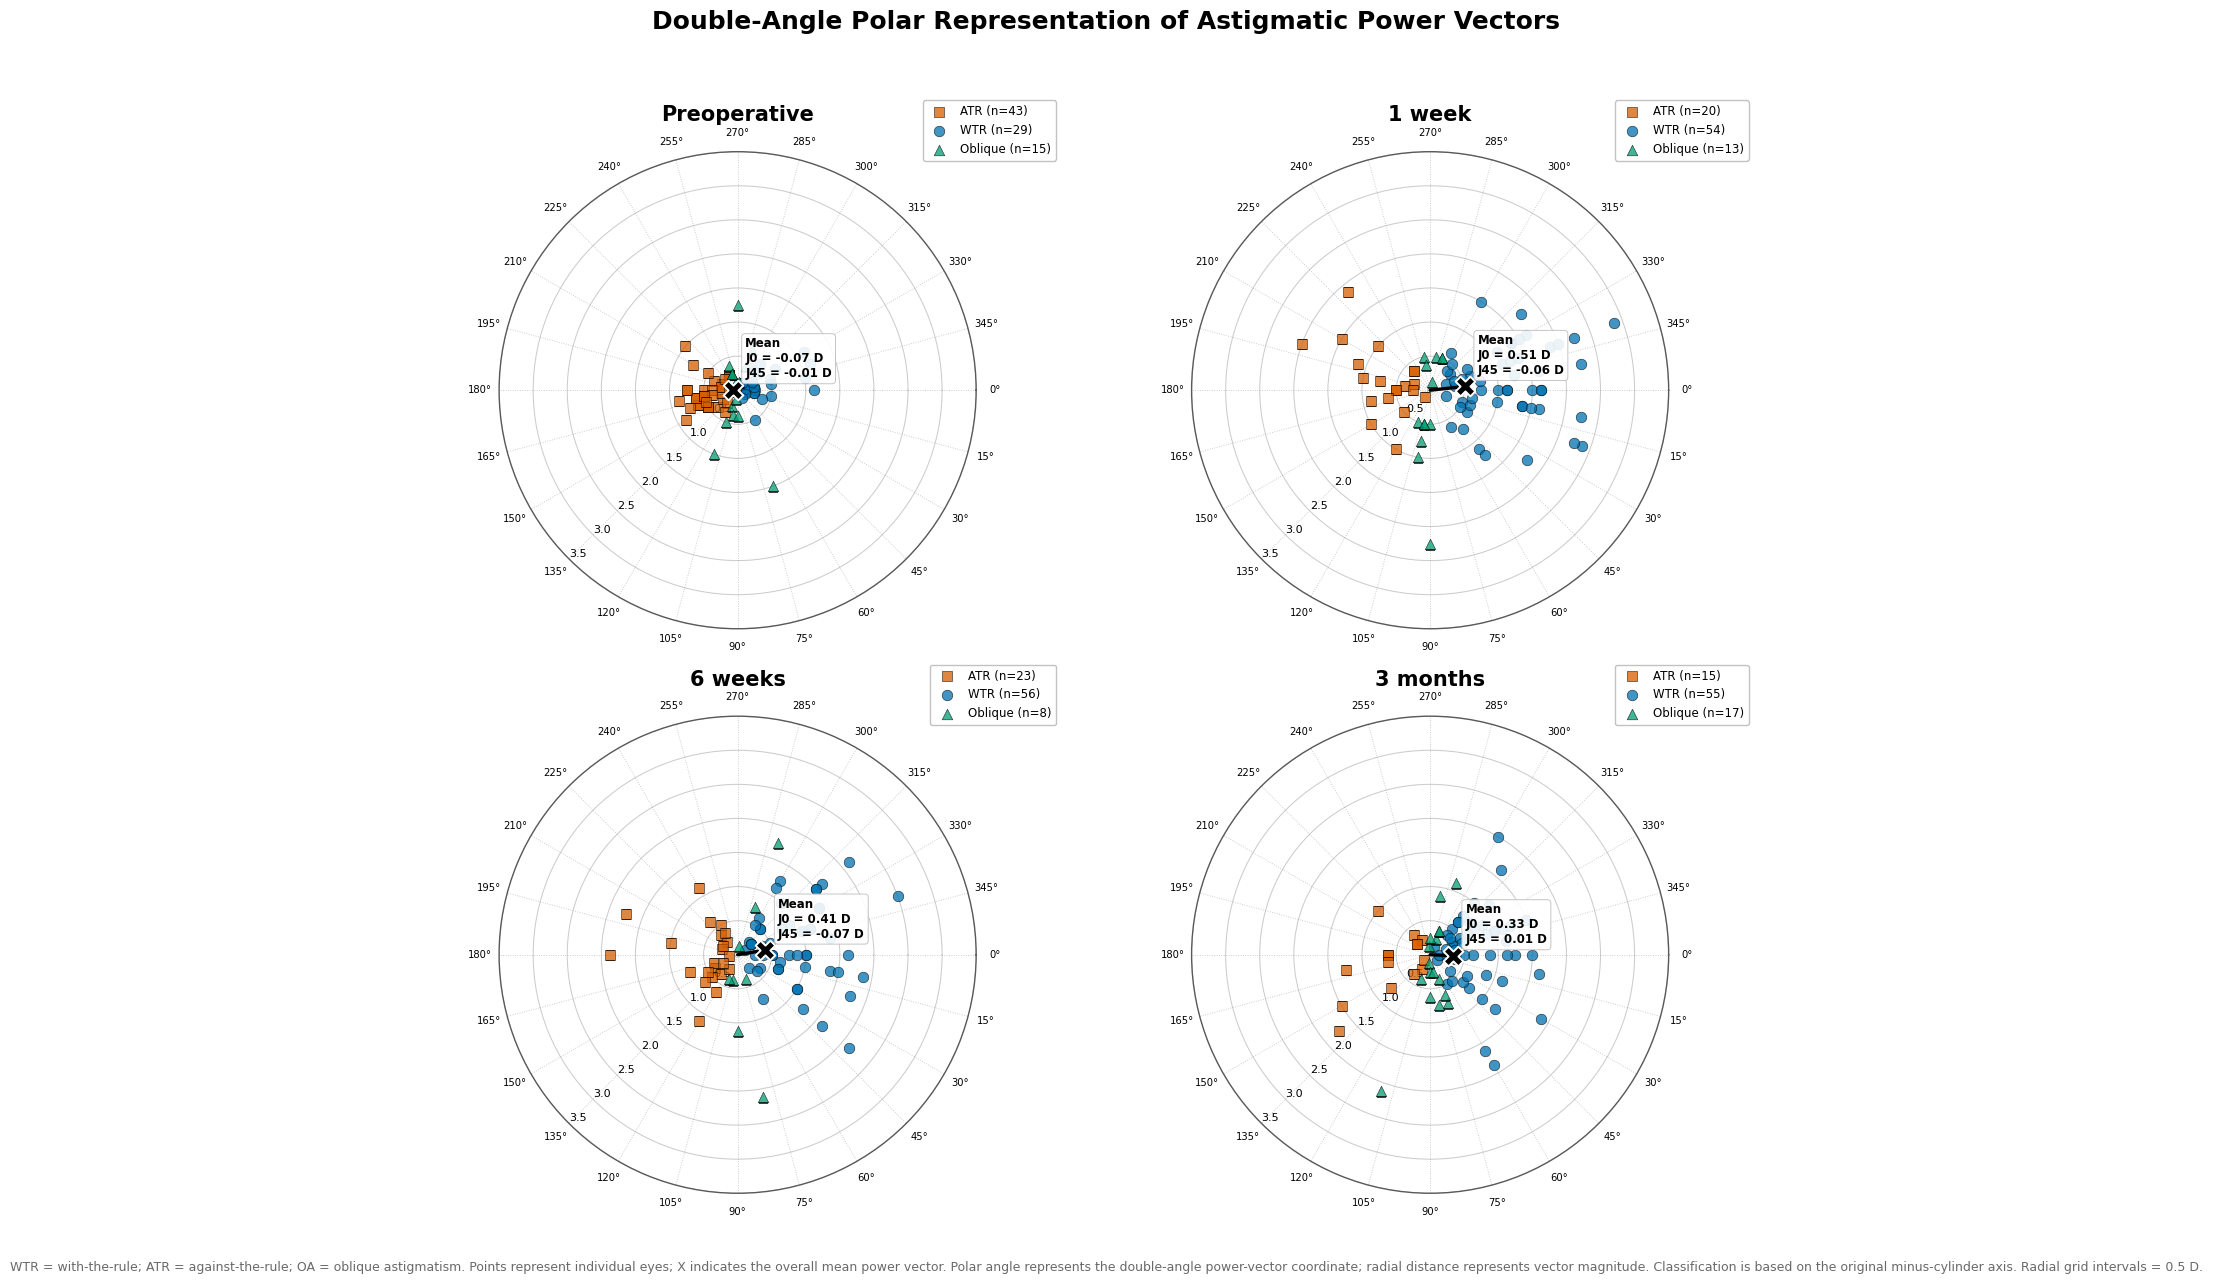

In [412]:
# ============================================================
# PUBLICATION-QUALITY 4-PANEL DOUBLE-ANGLE POLAR PLOTS
# THIBOS POWER-VECTOR ANALYSIS
#
# Preoperative → 1 week → 6 weeks → 3 months
#
# J0 / J45 represented using double-angle polar coordinates
#
# X/Y equivalent:
#     J0  = horizontal Cartesian component
#     J45 = vertical Cartesian component
#
# Polar representation:
#     radius = sqrt(J0² + J45²)
#     theta  = atan2(J45, J0)
#
# FEATURES:
#     • 15° angular intervals
#     • Concentric radial circles every 0.5 D
#     • Common radial scale across all panels
#     • WTR / ATR / Oblique classification
#     • Classification based on ORIGINAL minus-cylinder axis
#     • Mean astigmatic power vector
#     • Individual-eye scatter points
#     • 300-dpi PNG
#     • PDF export
# ============================================================


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# 1. TIME POINTS AND VARIABLES
# ============================================================

timepoints = {

    "Preoperative": {
        "J0": "Preop_J0",
        "J45": "Preop_J45",
        "Axis": "Preop_vector_axis"
    },

    "1 week": {
        "J0": "J0_1wk",
        "J45": "J45_1wk",
        "Axis": "Axis1wk_minus"
    },

    "6 weeks": {
        "J0": "J0_6wk",
        "J45": "J45_6wk",
        "Axis": "Axis6wk_minus"
    },

    "3 months": {
        "J0": "J0_3mth",
        "J45": "J45_3mth",
        "Axis": "Axis3mth_minus"
    }
}


# ============================================================
# 2. ASTIGMATISM CLASSIFICATION
# ============================================================
#
# Classification is based on the ORIGINAL MINUS-CYLINDER AXIS.
#
# Minus-cylinder axis:
#
#     ATR      = 0–30° or 150–180°
#     WTR      = 60–120°
#     Oblique  = 30–60° or 120–150°
#
# Relationship:
#
#     WTR → positive J0
#     ATR → negative J0
# ============================================================

def classify_astigmatism(axis):

    if pd.isna(axis):

        return np.nan

    axis = float(axis) % 180


    # --------------------------------------------------------
    # ATR
    # --------------------------------------------------------

    if axis <= 30 or axis >= 150:

        return "ATR"


    # --------------------------------------------------------
    # WTR
    # --------------------------------------------------------

    elif axis >= 60 and axis <= 120:

        return "WTR"


    # --------------------------------------------------------
    # OBLIQUE
    # --------------------------------------------------------

    else:

        return "Oblique"


# ============================================================
# 3. COLORS
# ============================================================

colors = {

    "ATR": "#D55E00",

    "WTR": "#0072B2",

    "Oblique": "#009E73"
}


# ============================================================
# 4. MARKERS
# ============================================================

markers = {

    "ATR": "s",

    "WTR": "o",

    "Oblique": "^"
}


# ============================================================
# 5. CATEGORY ORDER
# ============================================================

categories = [

    "ATR",

    "WTR",

    "Oblique"
]


# ============================================================
# 6. CLASSIFICATION SUMMARY
# ============================================================

summary_data = []


for time_label, cols in timepoints.items():

    axis_data = (

        sorted_data[
            cols["Axis"]
        ]
        .dropna()
    )


    total = len(axis_data)


    classified = axis_data.apply(
        classify_astigmatism
    )


    counts = classified.value_counts()


    for category in categories:

        count = counts.get(
            category,
            0
        )


        percentage = (

            count / total * 100

            if total > 0

            else np.nan
        )


        summary_data.append({

            "Time": time_label,

            "Astigmatism": category,

            "Count": count,

            "Percentage": percentage
        })


summary = pd.DataFrame(
    summary_data
)


# ============================================================
# 7. DISPLAY CLASSIFICATION CHECK
# ============================================================

print("\nASTIGMATISM TYPE DISTRIBUTION")
print("=" * 70)

display(
    summary.round(2)
)


# ============================================================
# 8. CALCULATE COMMON RADIAL LIMIT
# ============================================================

all_magnitudes = []


for cols in timepoints.values():

    temp = sorted_data[

        [
            cols["J0"],
            cols["J45"]
        ]

    ].dropna()


    magnitude = np.sqrt(

        temp[cols["J0"]] ** 2 +

        temp[cols["J45"]] ** 2
    )


    all_magnitudes.extend(

        magnitude.to_numpy()
    )


# ============================================================
# CHECK THAT DATA EXIST
# ============================================================

if len(all_magnitudes) == 0:

    raise ValueError(
        "No valid J0/J45 data were found."
    )


# ============================================================
# MAXIMUM VECTOR MAGNITUDE
# ============================================================

max_radius = np.nanmax(
    all_magnitudes
)


# ============================================================
# ROUND RADIAL LIMIT UPWARD
# ============================================================
#
# The limit is rounded to a convenient 0.5-D interval
# and one additional 0.5-D margin is added.
# ============================================================

radial_limit = (

    np.ceil(
        max_radius * 2
    ) / 2

    + 0.5
)


# ============================================================
# RADIAL TICKS EVERY 0.5 D
# ============================================================

radial_ticks = np.arange(

    0.5,

    radial_limit + 0.001,

    0.5
)


# ============================================================
# 15-DEGREE POLAR INTERVALS
# ============================================================
#
# Full polar circle:
#
#     0°, 15°, 30°, 45°, ... 345°
#
# These are DOUBLE-ANGLE polar coordinates.
# ============================================================

polar_positions = np.arange(

    0,

    360,

    15
)


polar_labels = [

    f"{int(angle)}°"

    for angle in polar_positions
]


# ============================================================
# 9. CREATE 4-PANEL POLAR FIGURE
# ============================================================

fig, axes = plt.subplots(

    2,

    2,

    figsize=(14, 13),

    subplot_kw={
        "projection": "polar"
    }
)


axes = axes.flatten()


# ============================================================
# 10. GENERATE EACH PANEL
# ============================================================

for ax, (time_label, cols) in zip(

    axes,

    timepoints.items()
):


    # ========================================================
    # EXTRACT J0 / J45 / ORIGINAL AXIS
    # ========================================================

    temp = sorted_data[

        [
            cols["J0"],
            cols["J45"],
            cols["Axis"]
        ]

    ].dropna().copy()


    temp.columns = [

        "J0",
        "J45",
        "Axis"
    ]


    # ========================================================
    # CLASSIFY ASTIGMATISM
    # ========================================================
    #
    # IMPORTANT:
    # Classification is based on the ORIGINAL
    # minus-cylinder axis.
    #
    # Do NOT recalculate classification from J0/J45.
    # ========================================================

    temp["Type"] = temp[
        "Axis"
    ].apply(
        classify_astigmatism
    )


    # ========================================================
    # VECTOR MAGNITUDE
    # ========================================================

    temp["Magnitude"] = np.sqrt(

        temp["J0"] ** 2 +

        temp["J45"] ** 2
    )


    # ========================================================
    # DOUBLE-ANGLE POLAR ANGLE
    # ========================================================
    #
    # theta = atan2(J45, J0)
    #
    # This is the double-angle representation of the
    # astigmatic power vector.
    # ========================================================

    temp["Theta"] = np.arctan2(

        temp["J45"],

        temp["J0"]
    )


    # ========================================================
    # PLOT EACH ASTIGMATISM CATEGORY
    # ========================================================

    for category in categories:


        subset = temp[
            temp["Type"] == category
        ]


        # ----------------------------------------------------
        # Skip empty category
        # ----------------------------------------------------

        if len(subset) == 0:

            continue


        # ----------------------------------------------------
        # SCATTER PLOT
        # ----------------------------------------------------

        ax.scatter(

            subset["Theta"],

            subset["Magnitude"],

            s=58,

            color=colors[category],

            marker=markers[category],

            alpha=0.75,

            edgecolor="black",

            linewidth=0.45,

            label=(
                f"{category} "
                f"(n={len(subset)})"
            ),

            zorder=4
        )


    # ========================================================
    # OVERALL MEAN J0 / J45
    # ========================================================

    mean_j0 = temp[
        "J0"
    ].mean()


    mean_j45 = temp[
        "J45"
    ].mean()


    # ========================================================
    # MEAN VECTOR MAGNITUDE
    # ========================================================

    mean_radius = np.sqrt(

        mean_j0 ** 2 +

        mean_j45 ** 2
    )


    # ========================================================
    # MEAN VECTOR ANGLE
    # ========================================================

    mean_theta = np.arctan2(

        mean_j45,

        mean_j0
    )


    # ========================================================
    # PLOT MEAN VECTOR
    # ========================================================

    ax.plot(

        [
            mean_theta,
            mean_theta
        ],

        [
            0,
            mean_radius
        ],

        color="black",

        linewidth=2.4,

        solid_capstyle="round",

        zorder=8
    )


    # ========================================================
    # MEAN VECTOR MARKER
    # ========================================================

    ax.scatter(

        mean_theta,

        mean_radius,

        marker="X",

        s=200,

        color="black",

        edgecolor="white",

        linewidth=1.4,

        zorder=10
    )


    # ========================================================
    # MEAN VECTOR LABEL
    # ========================================================

    ax.annotate(

        (
            f"Mean\n"
            f"J0 = {mean_j0:.2f} D\n"
            f"J45 = {mean_j45:.2f} D"
        ),

        xy=(

            mean_theta,

            mean_radius
        ),

        xytext=(

            9,

            9
        ),

        textcoords="offset points",

        fontsize=8.5,

        fontweight="bold",

        bbox=dict(

            boxstyle="round,pad=0.30",

            facecolor="white",

            edgecolor="0.75",

            linewidth=0.7,

            alpha=0.90
        ),

        zorder=11
    )


    # ========================================================
    # POLAR ORIENTATION
    # ========================================================
    #
    # 0° at the right-hand side.
    # ========================================================

    ax.set_theta_zero_location(
        "E"
    )


    # ========================================================
    # CLOCKWISE CLINICAL ORIENTATION
    # ========================================================

    ax.set_theta_direction(
        -1
    )


    # ========================================================
    # 15° ANGULAR INTERVALS
    # ========================================================

    ax.set_thetagrids(

        polar_positions,

        labels=polar_labels
    )


    # ========================================================
    # RADIAL LIMIT
    # ========================================================

    ax.set_rlim(

        0,

        radial_limit
    )


    # ========================================================
    # RADIAL TICKS EVERY 0.5 D
    # ========================================================

    ax.set_yticks(

        radial_ticks
    )


    ax.set_yticklabels(

        [
            f"{r:.1f}"
            for r in radial_ticks
        ]
    )


    # ========================================================
    # RADIAL LABEL POSITION
    # ========================================================

    ax.set_rlabel_position(
        135
    )


    # ========================================================
    # TICK FORMATTING
    # ========================================================

    ax.tick_params(

        axis="x",

        labelsize=7.2,

        pad=3
    )


    ax.tick_params(

        axis="y",

        labelsize=8
    )


    # ========================================================
    # ANGULAR GRID
    # ========================================================
    #
    # Light dotted lines every 15°.
    # ========================================================

    ax.xaxis.grid(

        True,

        linestyle=":",

        linewidth=0.65,

        color="gray",

        alpha=0.45
    )


    # ========================================================
    # RADIAL GRID
    # ========================================================
    #
    # Concentric circles every 0.5 D.
    # ========================================================

    ax.yaxis.grid(

        True,

        linestyle="-",

        linewidth=0.75,

        color="gray",

        alpha=0.40
    )


    # ========================================================
    # POLAR AXIS SPINE
    # ========================================================

    ax.spines["polar"].set_color(
        "0.35"
    )

    ax.spines["polar"].set_linewidth(
        1.0
    )


    # ========================================================
    # PANEL TITLE
    # ========================================================

    ax.set_title(

        time_label,

        fontsize=15,

        fontweight="bold",

        pad=22
    )


    # ========================================================
    # LEGEND
    # ========================================================

    ax.legend(

        fontsize=8.5,

        loc="upper right",

        bbox_to_anchor=(1.18, 1.12),

        frameon=True,

        framealpha=0.95,

        edgecolor="0.75"
    )


# ============================================================
# 11. MAIN TITLE
# ============================================================

fig.suptitle(

    "Double-Angle Polar Representation of Astigmatic Power Vectors",

    fontsize=18,

    fontweight="bold",

    y=0.985
)


# ============================================================
# 12. FOOTNOTE
# ============================================================

fig.text(

    0.5,

    0.015,

    (
        "WTR = with-the-rule; "
        "ATR = against-the-rule; "
        "OA = oblique astigmatism. "
        "Points represent individual eyes; "
        "X indicates the overall mean power vector. "
        "Polar angle represents the double-angle power-vector "
        "coordinate; radial distance represents vector magnitude. "
        "Classification is based on the original minus-cylinder axis. "
        "Radial grid intervals = 0.5 D."
    ),

    ha="center",

    fontsize=9,

    color="dimgray"
)


# ============================================================
# 13. FINAL LAYOUT
# ============================================================

plt.tight_layout(

    rect=[

        0,

        0.045,

        1,

        0.955
    ]
)


# ============================================================
# 14. SAVE HIGH-RESOLUTION PNG
# ============================================================

plt.savefig(

    "Double_Angle_Polar_Power_Vector_4Panel.png",

    dpi=300,

    bbox_inches="tight",

    facecolor="white"
)


# ============================================================
# 15. SAVE PDF
# ============================================================

plt.savefig(

    "Double_Angle_Polar_Power_Vector_4Panel.pdf",

    bbox_inches="tight",

    facecolor="white"
)


# ============================================================
# 16. DISPLAY
# ============================================================

plt.show()
